# How to Generate Temporal Music Activations with MusicGen

To generate temporal music activations using MusicGen, process audio through MusicGen and extract latent feature activations over time. Use the commands below from the repository root.

1. **Load the MusicGen model**: This is handled automatically by the extraction script.

2. **Prepare the audio input**: Ensure data/output directories exist and point to your audio folder.
Bash Script:
```bash
Scripts/SetupScripts/setup_data_dirs.sh
AUDIO_DIR="/path/to/audio/files"
```

3. **Process the audio through MusicGen**: Pass audio through MusicGen decoder and collect residual activations.
Bash Script:
```bash
Scripts/TrainingScripts/run_extract_musicgen_features.sh \
  "$AUDIO_DIR" \
  Data/Models/features \
  --max_files 16 \
  --max_duration_sec 30 \
  --decoder_layers 0,8,16,-1 \
  --pooling none \
  --metadata_json
```

4. **Extract temporal activations**: Saved per track and per layer under `Data/Models/features/layer_*`.

5. **Analyze the activations**(No Need to re extract activations unless you changed the audio input or the extraction parameters such as dataset size, max files, max duration, decoder layers, pooling): Train SAE without averaging away time (frame-level mode).
Bash Script:
```bash
Scripts/TrainingScripts/run_train_sae_[device] \
  Data/Models/features/layer_final \
  Output/sae-layer-final \
  --sample_mode frames \
  --frame_stride 4 \
  --max_frames 4096
```

6. **Visualize the results**: Open this notebook after extraction/training outputs exist.
Bash Script:
```bash
jupyter lab Analysis/temporal_feature_analysis.ipynb
```

# Temporal SAE Feature Analysis

This notebook analyzes the features learned by Sparse Autoencoders (SAEs) trained on
MusicGen decoder residual streams across all 24 extracted decoder representations:
`layer_00` through `layer_22`, plus `layer_final`.

For each trained SAE we summarize the temporal behavior of its 256 latent features
and categorize each feature into one of four temporal profile types:

| Category | Behaviour | Detector |
|---|---|---|
| **Static** | High, sustained activation throughout the track | Low temporal variance + high mean |
| **Structural / Periodic** | Oscillates predictably (intro -> verse -> chorus ...) | High autocorrelation peak at non-zero lag |
| **Narrative Arc** | Ramps up, peaks, or decays monotonically | Large magnitude linear trend slope |
| **Local Event** | Brief, isolated spikes (drum fill, key change) | High kurtosis (heavy-tailed distribution) |

The notebook is configured to sample up to 100 tracks per layer for fast iteration,
save plots into `Analysis/Output`, and compare temporal feature structure across all
available trained layers.

In [1]:
import sys
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch

# Resolve the repository root whether the kernel starts in Analysis/ or the repo root.
REPO_ROOT = Path(".").resolve().parent
if not (REPO_ROOT / "Temporal-Music-Activations").exists():
    REPO_ROOT = Path(".").resolve()

sys.path.insert(0, str(REPO_ROOT / "Temporal-Music-Activations"))

from SparseAutoencoder import SparseAutoencoder

LAYER_NAMES = [f"layer_{i:02d}" for i in range(23)] + ["layer_final"]
FEATURES_ROOT = Path("/scratch/general/vast/u1406806/sae_output/features-all-layers")
SAE_ROOT = Path("/scratch/general/vast/u1406806/sae_output/models-all-layers-stride1-repacked")

FEATURE_LAYER_BY_RUN = {name: name for name in LAYER_NAMES}
SAE_DIR_BY_RUN = {name: name for name in LAYER_NAMES}

INPUT_DIM = 1024
LATENT_DIM = 256
DEVICE = "cpu"
MAX_TRACKS = 100
ANALYSIS_SEED = 0
VIS_TRACKS = 1

OUTPUT_DIR = REPO_ROOT / "Analysis" / "Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Features root:", FEATURES_ROOT)
print("SAE root:", SAE_ROOT)
print("Layers:", len(LAYER_NAMES), LAYER_NAMES[0], "...", LAYER_NAMES[-1])
print("Track sample budget per layer:", MAX_TRACKS)
print("Output dir:", OUTPUT_DIR)

Matplotlib is building the font cache; this may take a moment.


Repo root: /uufs/chpc.utah.edu/common/home/u1406806/Interpretability-of-Temporal-Music-Activations-in-AudioGen
Features root: /scratch/general/vast/u1406806/sae_output/features-all-layers
SAE root: /scratch/general/vast/u1406806/sae_output/models-all-layers-stride1-repacked
Layers: 24 layer_00 ... layer_final
Track sample budget per layer: 100
Output dir: /uufs/chpc.utah.edu/common/home/u1406806/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Analysis/Output


## 1 · Load SAE Models

We load the final-epoch checkpoint for each layer that has finished training.
Layers whose `sae_final.pt` does not yet exist are skipped with a notice.


In [2]:
def load_sae(layer_name: str) -> SparseAutoencoder | None:
    """Load the best available SAE checkpoint for a layer."""
    sae_dir = SAE_DIR_BY_RUN[layer_name]
    checkpoint_candidates = [
        SAE_ROOT / sae_dir / "sae_best.pt",
        SAE_ROOT / sae_dir / "sae_final.pt",
    ]
    ckpt_path = next((path for path in checkpoint_candidates if path.exists()), None)
    if ckpt_path is None:
        print(f"  [skip] {layer_name}: no checkpoint found in {SAE_ROOT / sae_dir}")
        return None

    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    state = ckpt["model_state_dict"]
    input_dim = state["encoder.weight"].shape[1]
    latent_dim = state["encoder.weight"].shape[0]

    model = SparseAutoencoder(input_dim, latent_dim).to(DEVICE)
    model.load_state_dict(state)
    model.eval()

    print(
        f"  [ok]   {layer_name}: loaded {ckpt_path.name} "
        f"(epoch {ckpt['epoch']}, input={input_dim}, latent={latent_dim})"
    )
    return model


print("Loading SAE checkpoints:")
sae_models: Dict[str, SparseAutoencoder] = {}
for layer in LAYER_NAMES:
    model = load_sae(layer)
    if model is not None:
        sae_models[layer] = model

print(f"\nReady: {len(sae_models)} layers")

Loading SAE checkpoints:
  [ok]   layer_00: loaded sae_best.pt (epoch 0, input=1024, latent=256)
  [ok]   layer_01: loaded sae_best.pt (epoch 0, input=1024, latent=256)
  [ok]   layer_02: loaded sae_best.pt (epoch 2, input=1024, latent=256)
  [ok]   layer_03: loaded sae_best.pt (epoch 1, input=1024, latent=256)
  [ok]   layer_04: loaded sae_best.pt (epoch 1, input=1024, latent=256)
  [ok]   layer_05: loaded sae_best.pt (epoch 7, input=1024, latent=256)
  [ok]   layer_06: loaded sae_best.pt (epoch 0, input=1024, latent=256)
  [ok]   layer_07: loaded sae_best.pt (epoch 0, input=1024, latent=256)
  [ok]   layer_08: loaded sae_best.pt (epoch 1, input=1024, latent=256)
  [ok]   layer_09: loaded sae_best.pt (epoch 1, input=1024, latent=256)
  [ok]   layer_10: loaded sae_best.pt (epoch 2, input=1024, latent=256)
  [ok]   layer_11: loaded sae_best.pt (epoch 1, input=1024, latent=256)
  [ok]   layer_12: loaded sae_best.pt (epoch 2, input=1024, latent=256)
  [ok]   layer_13: loaded sae_best.pt (

## 2 · Dense Encoding – Run SAE on Every Frame

For each `.npy` feature file `[T, 1024]` we pass all T frames through the SAE encoder
(no stride) to get a per-track activation matrix `[T, 128]`.  These are stored in
`activations[layer_name]` as a list of numpy arrays, one per track.


In [5]:
def collect_npy_files(layer_name: str) -> List[Path]:
    """Return the sorted .npy feature files for the feature layer backing a run."""
    feature_layer = FEATURE_LAYER_BY_RUN[layer_name]
    layer_dir = FEATURES_ROOT / feature_layer
    return sorted(layer_dir.rglob("*.npy"))


def sample_npy_files(layer_name: str, npy_files: List[Path]) -> List[Path]:
    """Deterministically subsample tracks for faster analysis runs."""
    if not MAX_TRACKS or len(npy_files) <= MAX_TRACKS:
        return npy_files

    seed = ANALYSIS_SEED + sum(ord(ch) for ch in layer_name)
    rng = np.random.default_rng(seed)
    indices = np.sort(rng.choice(len(npy_files), size=MAX_TRACKS, replace=False))
    return [npy_files[int(index)] for index in indices]


def encode_layer(layer_name: str, model: SparseAutoencoder) -> List[np.ndarray]:
    """Encode every frame of each sampled track for a given layer."""
    all_npy_files = collect_npy_files(layer_name)
    if not all_npy_files:
        print(f"  [warn] No .npy files found for {layer_name}")
        return []

    npy_files = sample_npy_files(layer_name, all_npy_files)
    input_dim = model.encoder.weight.shape[1]
    track_activations: List[np.ndarray] = []

    with torch.no_grad():
        for path in npy_files:
            features = np.load(path)
            if features.ndim != 2 or features.shape[1] != input_dim:
                print(
                    f"  [warn] Skipping {path.name}: unexpected shape {features.shape} "
                    f"(expected [T, {input_dim}])"
                )
                continue

            x = torch.tensor(features, dtype=torch.float32).to(DEVICE)
            latent = model.activation(model.encoder(x))
            track_activations.append(latent.cpu().numpy())

    total_frames = sum(act.shape[0] for act in track_activations)
    sampled_note = ""
    if len(npy_files) != len(all_npy_files):
        sampled_note = f" (sampled {len(npy_files)} / {len(all_npy_files)} tracks)"

    print(
        f"  {layer_name}: {len(track_activations)} tracks, {total_frames:,} total frames"
        f"{sampled_note}"
    )
    return track_activations


print("Encoding all frames:")
activations: Dict[str, List[np.ndarray]] = {}
for layer_name, model in sae_models.items():
    activations[layer_name] = encode_layer(layer_name, model)

print("\nSample shapes [T, latent_dim]:")
for layer_name, acts in activations.items():
    if acts:
        print(f"  {layer_name}: {acts[0].shape}")

Encoding all frames:
  layer_00: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_01: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_02: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_03: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_04: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_05: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_06: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_07: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_08: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)
  layer_09: 100 tracks, 150,000 total frames (sampled 100 / 55701 tracks)


: 

## 9 · Training Curves (Loss / Recon / Sparsity)

This section automatically loads each layer's `training_metrics.csv` written during SAE training and plots:

1. `avg_loss` vs epoch
2. `avg_recon` vs epoch
3. `avg_sparsity` vs epoch

If a metrics CSV is missing for a layer, it is skipped with a warning.


  [ok] layer_00: 50 epochs
  [ok] layer_01: 50 epochs
  [ok] layer_02: 48 epochs
  [ok] layer_03: 48 epochs
  [ok] layer_04: 48 epochs
  [ok] layer_05: 50 epochs
  [ok] layer_06: 50 epochs
  [ok] layer_07: 50 epochs
  [ok] layer_08: 50 epochs
  [ok] layer_09: 48 epochs
  [ok] layer_10: 50 epochs
  [ok] layer_11: 50 epochs
  [ok] layer_12: 50 epochs
  [ok] layer_13: 50 epochs
  [ok] layer_14: 50 epochs
  [ok] layer_15: 50 epochs
  [ok] layer_16: 47 epochs
  [ok] layer_17: 50 epochs
  [ok] layer_18: 50 epochs
  [ok] layer_19: 50 epochs
  [ok] layer_20: 23 epochs
  [ok] layer_21: 24 epochs
  [ok] layer_22: 50 epochs
  [ok] layer_final: 50 epochs

Saved: /uufs/chpc.utah.edu/common/home/u1406806/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Analysis/Output/analysis_training_curves.png


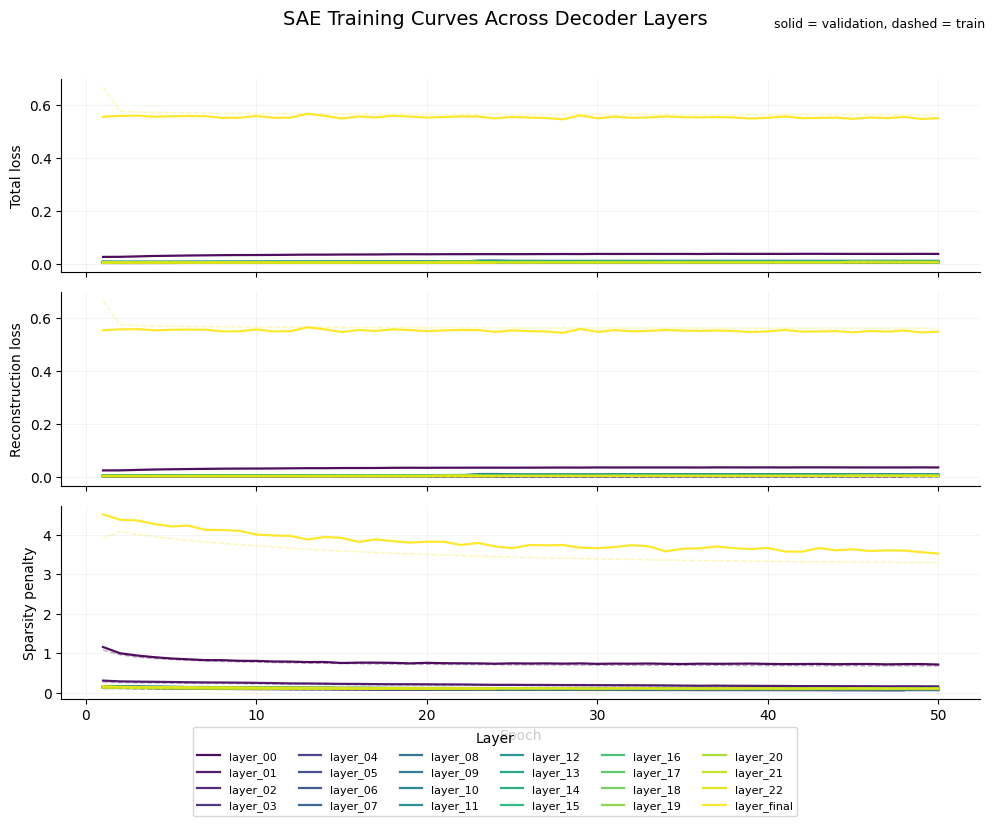

In [4]:
import pandas as pd

def load_training_metrics(layer_name: str) -> pd.DataFrame | None:
    """Load training_metrics.csv for a given SAE run, if it exists."""
    sae_dir = SAE_DIR_BY_RUN[layer_name]
    csv_path = SAE_ROOT / sae_dir / "training_metrics.csv"
    if not csv_path.exists():
        print(f"  [skip] {layer_name}: {csv_path} not found")
        return None
    df = pd.read_csv(csv_path)
    df["layer"] = layer_name
    return df


metrics_per_layer: Dict[str, pd.DataFrame] = {}
for layer in LAYER_NAMES:
    df = load_training_metrics(layer)
    if df is not None:
        metrics_per_layer[layer] = df
        print(f"  [ok] {layer}: {len(df)} epochs")

if not metrics_per_layer:
    print("No training_metrics.csv files found - skipping training curve plots.")
else:
    metrics_cols = [
        ("loss", "Total loss"),
        ("recon", "Reconstruction loss"),
        ("sparsity", "Sparsity penalty"),
    ]
    layer_order = [layer for layer in LAYER_NAMES if layer in metrics_per_layer]
    colors = plt.cm.viridis(np.linspace(0, 1, len(layer_order)))

    fig, axes = plt.subplots(len(metrics_cols), 1, figsize=(10, 8), sharex=True)
    fig.suptitle("SAE Training Curves Across Decoder Layers", fontsize=14, y=0.995)

    for axis, (metric_suffix, label) in zip(axes, metrics_cols):
        train_col = f"train_{metric_suffix}"
        val_col = f"val_{metric_suffix}"

        for color, layer_name in zip(colors, layer_order):
            df = metrics_per_layer[layer_name]
            if train_col in df.columns:
                axis.plot(
                    df["epoch"],
                    df[train_col],
                    color=color,
                    linewidth=1.0,
                    alpha=0.35,
                    linestyle="--",
                )
            if val_col in df.columns:
                axis.plot(
                    df["epoch"],
                    df[val_col],
                    color=color,
                    linewidth=1.6,
                    alpha=0.95,
                    label=layer_name,
                )

        axis.set_ylabel(label, fontsize=10)
        axis.grid(alpha=0.2, linewidth=0.5)
        for spine in ["top", "right"]:
            axis.spines[spine].set_visible(False)

    axes[-1].set_xlabel("Epoch", fontsize=10)
    fig.text(0.99, 0.985, "solid = validation, dashed = train", ha="right", va="top", fontsize=9)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=6, fontsize=8, title="Layer")

    plt.tight_layout(rect=(0, 0.06, 1, 0.97))
    out_path = OUTPUT_DIR / "analysis_training_curves.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"\nSaved: {out_path}")
    plt.show()

## 3 · Temporal Statistics per Feature

For each of the 128 SAE features we compute five scalar statistics, averaged across all
tracks in the dataset:

| Statistic | Formula | What it measures |
|---|---|---|
| `mean_act` | $\bar{a}_j$ | How often / strongly this feature fires |
| `frac_active` | $P(a_j > 0)$ | Feature sparsity |
| `temporal_var` | $\overline{\text{Var}_t(a_{ij})}$ | How much the feature fluctuates over time |
| `autocorr_peak` | $\max_{k>0} R_{jj}(k)$ | Strongest periodic echo at a non-zero lag |
| `kurtosis` | $\overline{\kappa_i(a_{ij})}$ | Peakedness / impulsiveness of the time series |
| `trend_slope` | $\overline{|m_{ij}|}$ | Magnitude of a linear trend over the track |


In [ ]:
import warnings


def autocorr_peak(series: np.ndarray, max_lag: int = 0) -> float:
    """Return the highest normalised autocorrelation at lags 1..max_lag.

    max_lag defaults to 0, which sets it adaptively to half the series length
    (capped at 1000).  A fixed small default (e.g. 50) would miss verse-chorus
    cycles in 30-second tracks: at ~50 tokens/s those cycles are 400-800 lags
    apart, well beyond a lag-50 window.
    """
    if series.std() < 1e-8:
        return 0.0
    n = len(series)
    if max_lag <= 0:
        max_lag = min(n // 2, 1000)
    max_lag = min(max_lag, n - 1)  # can't exceed series length
    s = series - series.mean()
    # full autocorrelation via np.correlate, normalised at lag 0
    full = np.correlate(s, s, mode="full")
    mid  = len(full) // 2
    ac   = full[mid:mid + max_lag + 1] / (full[mid] + 1e-12)
    return float(ac[1:].max())  # skip lag-0 (always 1)


def track_stats_for_feature(
    track_acts: List[np.ndarray], feat_idx: int
) -> dict:
    """
    Given all per-track activation matrices, compute scalar statistics for one
    feature by aggregating over tracks (mean of per-track values).
    """
    means, frac_actives, tvars, acs, kurts, slopes = [], [], [], [], [], []

    for act in track_acts:          # act: [T, lat_dim]
        ts = act[:, feat_idx]       # time series for this feature, this track
        T  = len(ts)
        if T < 4:
            continue

        means.append(ts.mean())
        frac_actives.append((ts > 0).mean())
        tvars.append(ts.var())
        acs.append(autocorr_peak(ts))

        # kurtosis: Fisher definition (normal → 0); high = spiky
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kurts.append(float(stats.kurtosis(ts, fisher=True)))

        # linear trend: fit degree-1 polynomial, take |slope|
        t = np.arange(T, dtype=float) / T  # normalise time to [0,1]
        slope = np.polyfit(t, ts, 1)[0]
        slopes.append(abs(slope))

    def safe_mean(lst):
        return float(np.mean(lst)) if lst else 0.0

    return {
        "mean_act":      safe_mean(means),
        "frac_active":   safe_mean(frac_actives),
        "temporal_var":  safe_mean(tvars),
        "autocorr_peak": safe_mean(acs),
        "kurtosis":      safe_mean(kurts),
        "trend_slope":   safe_mean(slopes),
    }


def compute_stats(layer_name: str) -> np.ndarray | None:
    """
    Returns a structured numpy array of shape [lat_dim] with fields:
    mean_act, frac_active, temporal_var, autocorr_peak, kurtosis, trend_slope.
    Infers lat_dim from the activation arrays so mixed-latent-dim runs (e.g.
    layer-final=64, layer-final-large-01=128) are handled correctly.
    """
    track_acts = activations.get(layer_name)
    if not track_acts:
        return None

    lat_dim = track_acts[0].shape[1]  # infer from data, not global constant

    dtype = np.dtype([
        ("mean_act",      float),
        ("frac_active",   float),
        ("temporal_var",  float),
        ("autocorr_peak", float),
        ("kurtosis",      float),
        ("trend_slope",   float),
    ])
    records = np.zeros(lat_dim, dtype=dtype)

    for j in range(lat_dim):
        row = track_stats_for_feature(track_acts, j)
        for field in dtype.names:
            records[j][field] = row[field]

    return records


# ── Compute for all available layers ─────────────────────────────────────────
print("Computing temporal statistics (this takes ~30 s for 100 tracks × 128 features)…")
stats_per_layer: Dict[str, np.ndarray] = {}
for layer_name in sae_models:
    print(f"  processing {layer_name}…")
    s = compute_stats(layer_name)
    if s is not None:
        stats_per_layer[layer_name] = s
        print(f"    done — mean activation range: "
              f"[{s['mean_act'].min():.4f}, {s['mean_act'].max():.4f}]")

print("\nStats ready for:", list(stats_per_layer.keys()))


Computing temporal statistics (this takes ~30 s for 100 tracks × 128 features)…
  processing layer_00…
    done — mean activation range: [0.0000, 0.3824]
  processing layer_08…
    done — mean activation range: [0.0000, 0.4357]
  processing layer_16…
    done — mean activation range: [0.0000, 0.3055]
  processing layer-final…
    done — mean activation range: [0.0001, 6.0623]
  processing layer-final-large-01…
    done — mean activation range: [0.0000, 4.0679]

Stats ready for: ['layer_00', 'layer_08', 'layer_16', 'layer-final', 'layer-final-large-01']


## 4 · Feature Classification

We normalise each of the five diagnostic statistics to $[0,1]$ across features and define
a **profile score** for each category:

$$
\text{Static}  = \hat{a}_\text{mean} \cdot (1 - \hat{\sigma}^2_t)
\qquad
\text{Periodic} = \hat{R}_\text{peak}
\qquad
\text{Narrative} = \hat{m}
\qquad
\text{Local} = \hat{\kappa}
$$

Each feature is assigned to the category whose score is highest.  Features with very low
mean activation ($\bar{a}_j < \epsilon$) are labelled **Dead** (never fires).


In [ ]:
from typing import Tuple as _Tuple  # noqa: F401 — used in annotation below

CATEGORIES   = ["Static", "Structural/Periodic", "Narrative Arc", "Local Event", "Dead"]
CATEGORY_COLORS = {
    "Static":               "#4C72B0",
    "Structural/Periodic":  "#DD8452",
    "Narrative Arc":        "#55A868",
    "Local Event":          "#C44E52",
    "Dead":                 "#999999",
}

# Features whose mean activation is below this threshold are considered dead.
DEAD_THRESHOLD = 0.01


def minmax(arr: np.ndarray) -> np.ndarray:
    """Min-max normalise to [0, 1].  Constant arrays map to 0."""
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-12)


def classify_features(s: np.ndarray) -> _Tuple[np.ndarray, np.ndarray]:
    """
    s: structured array of shape [LATENT_DIM] with temporal statistics fields.

    Returns (labels, scores):
      labels: string array of shape [LATENT_DIM] with category names.
      scores: float array of shape [LATENT_DIM, 4] with raw per-category scores.
    """
    # ── dead features first ───────────────────────────────────────────────────
    dead_mask = s["mean_act"] < DEAD_THRESHOLD

    # ── normalise each diagnostic to [0, 1] ──────────────────────────────────
    norm_mean   = minmax(s["mean_act"])
    norm_var    = minmax(s["temporal_var"])
    norm_ac     = minmax(s["autocorr_peak"])
    norm_kurt   = minmax(s["kurtosis"])
    norm_slope  = minmax(s["trend_slope"])

    # ── profile scores ────────────────────────────────────────────────────────
    # Static:   high mean activation AND low temporal variance
    score_static    = norm_mean * (1.0 - norm_var)
    # Structural: strong periodic echo at non-zero lag
    score_periodic  = norm_ac
    # Narrative: large linear trend slope
    score_narrative = norm_slope
    # Local event: spiky (high kurtosis), but NOT high mean
    score_local     = norm_kurt * (1.0 - norm_mean)

    # Stack scores and pick the winner per feature
    scores = np.stack([score_static, score_periodic, score_narrative, score_local], axis=1)
    winners = scores.argmax(axis=1)
    label_map = {0: "Static", 1: "Structural/Periodic", 2: "Narrative Arc", 3: "Local Event"}
    labels = np.array([label_map[w] for w in winners])

    # Overwrite dead features regardless of scores
    labels[dead_mask] = "Dead"
    return labels, scores


# ── Classify for all available layers ────────────────────────────────────────
labels_per_layer: Dict[str, np.ndarray]  = {}
scores_per_layer: Dict[str, np.ndarray]  = {}

for layer_name, s in stats_per_layer.items():
    lbl, scr = classify_features(s)
    labels_per_layer[layer_name] = lbl
    scores_per_layer[layer_name] = scr
    counts = {c: int((lbl == c).sum()) for c in CATEGORIES if (lbl == c).sum() > 0}
    print(f"{layer_name}: {counts}")


layer_00: {'Local Event': 117, 'Dead': 11}
layer_08: {'Local Event': 32, 'Dead': 96}
layer_16: {'Local Event': 25, 'Dead': 103}
layer-final: {'Local Event': 45, 'Dead': 19}
layer-final-large-01: {'Local Event': 105, 'Dead': 23}


## 5 · Category Distribution

How many of the 128 SAE features fall into each temporal profile category?


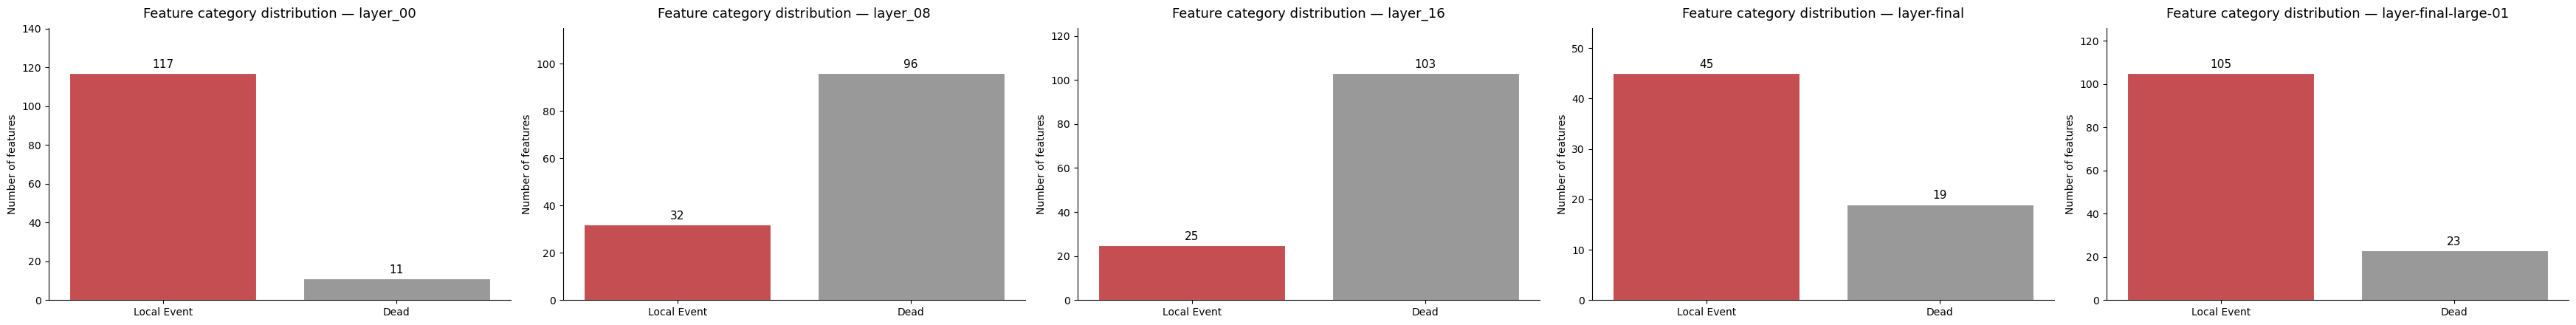

In [ ]:
def plot_category_distribution(layer_name: str, labels: np.ndarray, ax=None):
    """Bar chart of feature category counts for one layer."""
    counts = {category: int((labels == category).sum()) for category in CATEGORIES}
    cats = [category for category in CATEGORIES if counts[category] > 0]
    vals = [counts[category] for category in cats]
    colors = [CATEGORY_COLORS[category] for category in cats]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    bars = ax.bar(cats, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_title(layer_name, fontsize=11, pad=8)
    ax.set_ylabel("Features", fontsize=9)
    ax.set_ylim(0, max(vals) * 1.2 if vals else 1)
    ax.tick_params(axis="x", labelsize=8, rotation=25)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


available = [layer for layer in LAYER_NAMES if layer in labels_per_layer]
if not available:
    print("No classified layers available - skipping category distribution plot.")
else:
    n_layers = len(available)
    ncols = min(4, n_layers)
    nrows = int(np.ceil(n_layers / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.8 * nrows), squeeze=False)
    fig.suptitle("Feature Category Distribution by Decoder Layer", fontsize=14, y=0.995)

    flat_axes = axes.ravel()
    for index, layer_name in enumerate(available):
        plot_category_distribution(layer_name, labels_per_layer[layer_name], ax=flat_axes[index])

    for index in range(n_layers, len(flat_axes)):
        flat_axes[index].axis("off")

    plt.tight_layout(rect=(0, 0, 1, 0.97))
    out_path = OUTPUT_DIR / "analysis_category_distribution.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

## 6 · Example Activation Time Series per Category

For each category we pick the **top-3 scoring features** and plot their average activation
time series across all tracks, normalised to $[0,1]$.  This gives an intuitive visual
signature for each profile type.


Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_timeseries_layer_00.png


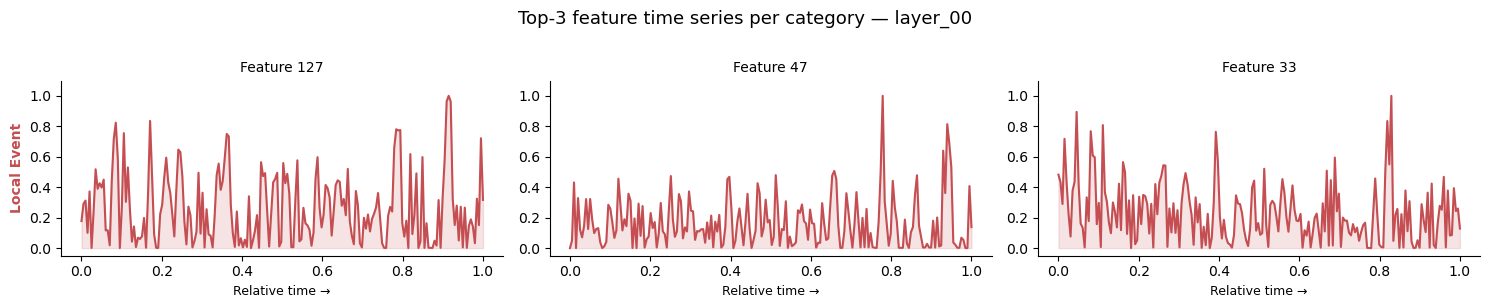

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_timeseries_layer_08.png


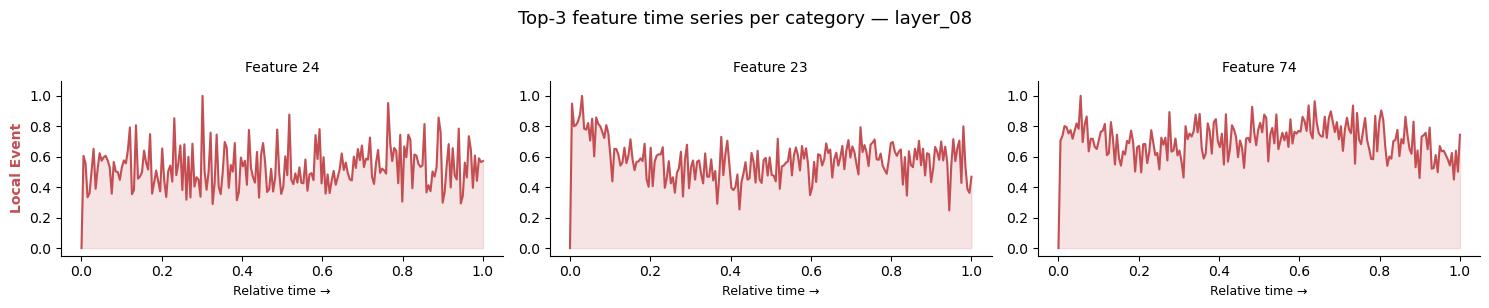

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_timeseries_layer_16.png


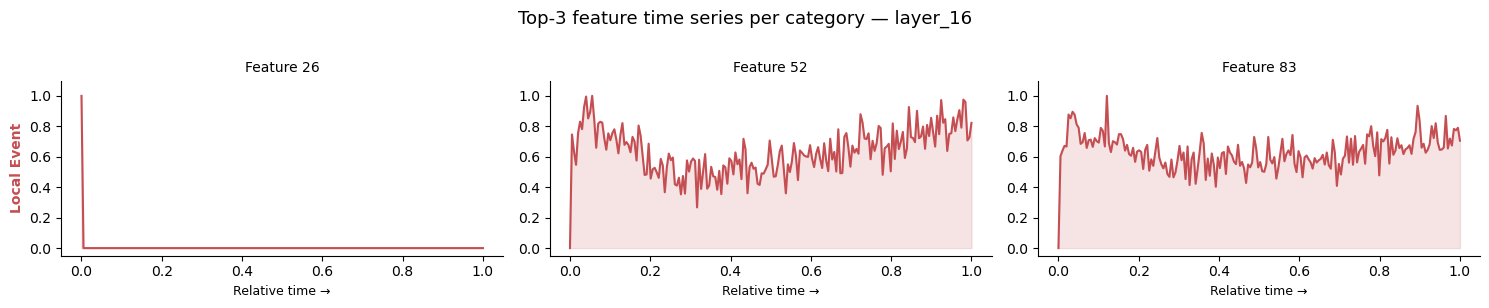

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_timeseries_layer-final.png


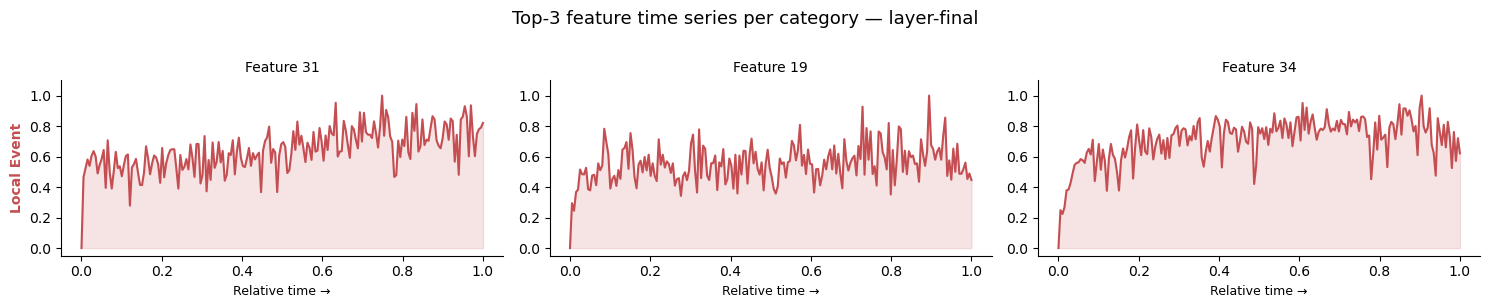

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_timeseries_layer-final-large-01.png


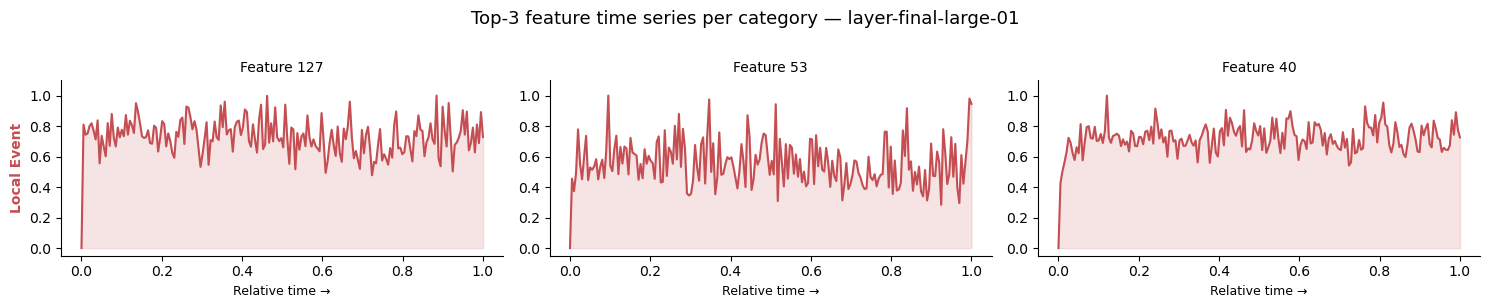

In [ ]:
def top_features_for_category(
    category: str,
    labels: np.ndarray,
    scores: np.ndarray,
    n: int = 3,
) -> List[int]:
    """Return the indices of the n features with the highest winning score in this category."""
    cat_idx = ["Static", "Structural/Periodic", "Narrative Arc", "Local Event"].index(category)
    mask = labels == category
    if mask.sum() == 0:
        return []

    cat_scores = scores[:, cat_idx].copy()
    cat_scores[~mask] = -np.inf
    return list(np.argsort(cat_scores)[::-1][:n])


def avg_time_series(feat_idx: int, track_acts: List[np.ndarray], n_bins: int = 200) -> np.ndarray:
    """Compute a mean activation time series for one feature across tracks."""
    resampled = []
    for act in track_acts:
        ts = act[:, feat_idx]
        if len(ts) < 2:
            continue
        x_old = np.linspace(0, 1, len(ts))
        x_new = np.linspace(0, 1, n_bins)
        resampled.append(np.interp(x_new, x_old, ts))
    if not resampled:
        return np.zeros(n_bins)
    return np.mean(resampled, axis=0)


def plot_category_timeseries(layer_name: str, top_n: int = 3):
    track_acts = activations[layer_name]
    labels = labels_per_layer[layer_name]
    scores = scores_per_layer[layer_name]

    active_categories = [category for category in CATEGORIES[:-1] if (labels == category).sum() > 0]
    n_categories = len(active_categories)

    fig, axes = plt.subplots(
        n_categories,
        top_n,
        figsize=(5 * top_n, 3 * n_categories),
        sharex=True,
        sharey=False,
    )
    if n_categories == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(f"Top-{top_n} Feature Time Series per Category - {layer_name}", fontsize=13, y=1.01)
    x_axis = np.linspace(0, 1, 200)

    for row, category in enumerate(active_categories):
        top_features = top_features_for_category(category, labels, scores, n=top_n)
        color = CATEGORY_COLORS[category]

        for col in range(top_n):
            ax = axes[row, col]
            if col < len(top_features):
                feature_index = top_features[col]
                ts = avg_time_series(feature_index, track_acts)
                ts_norm = (ts - ts.min()) / (ts.max() - ts.min() + 1e-12)
                ax.plot(x_axis, ts_norm, color=color, linewidth=1.5)
                ax.fill_between(x_axis, ts_norm, alpha=0.15, color=color)
                ax.set_title(f"Feature {feature_index}", fontsize=10)
                ax.set_ylim(-0.05, 1.1)
                for spine in ["top", "right"]:
                    ax.spines[spine].set_visible(False)
            else:
                ax.axis("off")

            if col == 0:
                ax.set_ylabel(category, fontsize=10, color=color, fontweight="bold")
            if row == n_categories - 1:
                ax.set_xlabel("Relative time", fontsize=9)

    plt.tight_layout()
    out_path = OUTPUT_DIR / f"analysis_timeseries_{layer_name}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()


for layer_name in labels_per_layer:
    plot_category_timeseries(layer_name)

## 7 · Per-Track Activation Heatmap

A `[features × time]` heatmap for individual tracks with features sorted by category
(Static → Structural → Narrative → Local → Dead).  This is the core visualisation of
the project: you can see the temporal structure of all 128 features at once for a
single track.


Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_00_track0.png


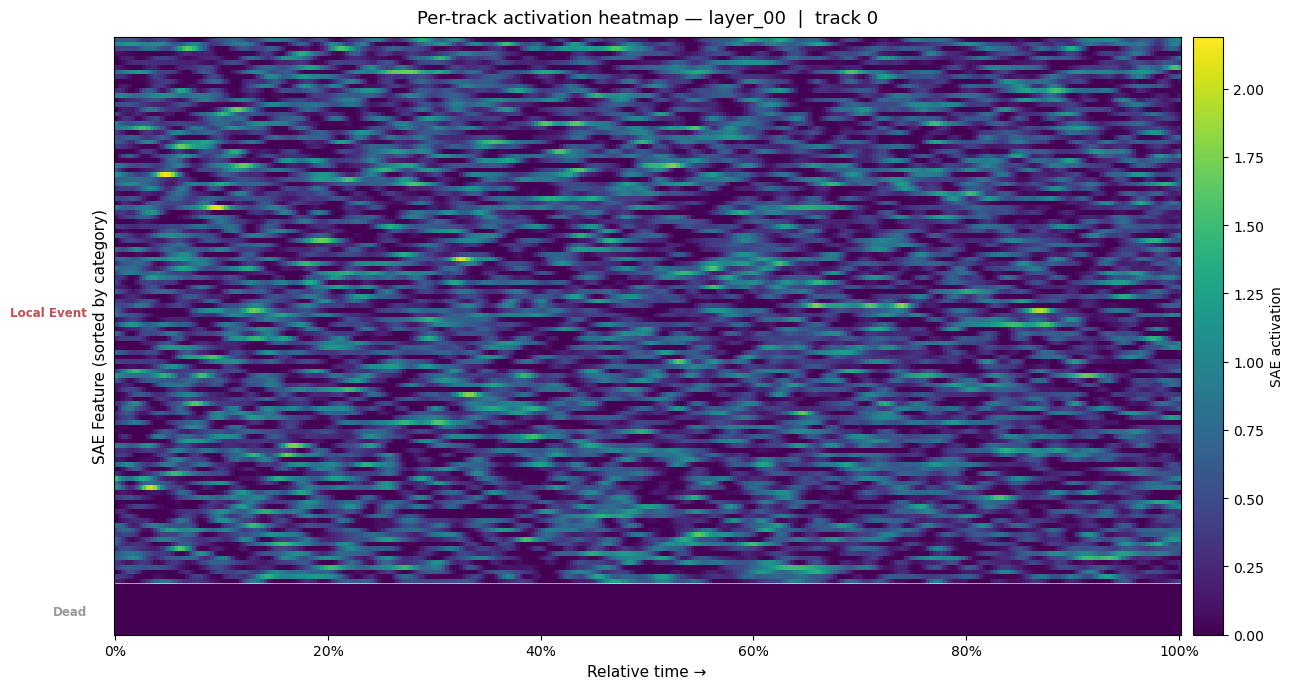

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_00_track24.png


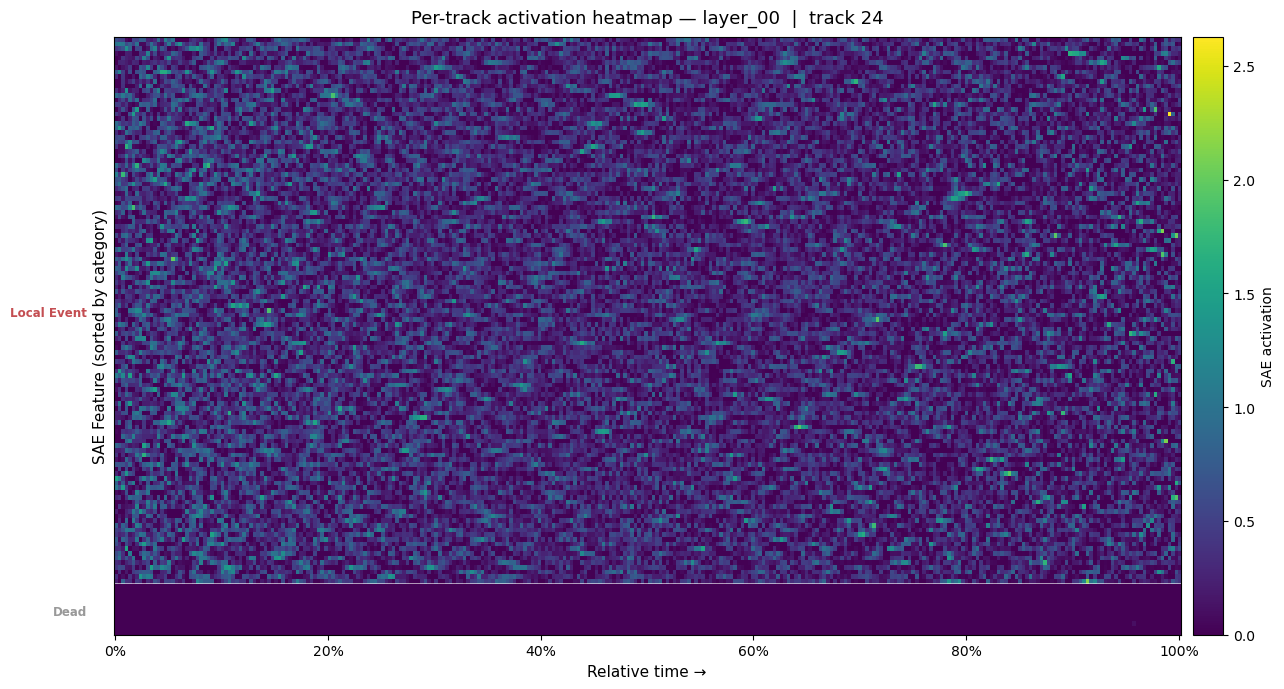

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_00_track49.png


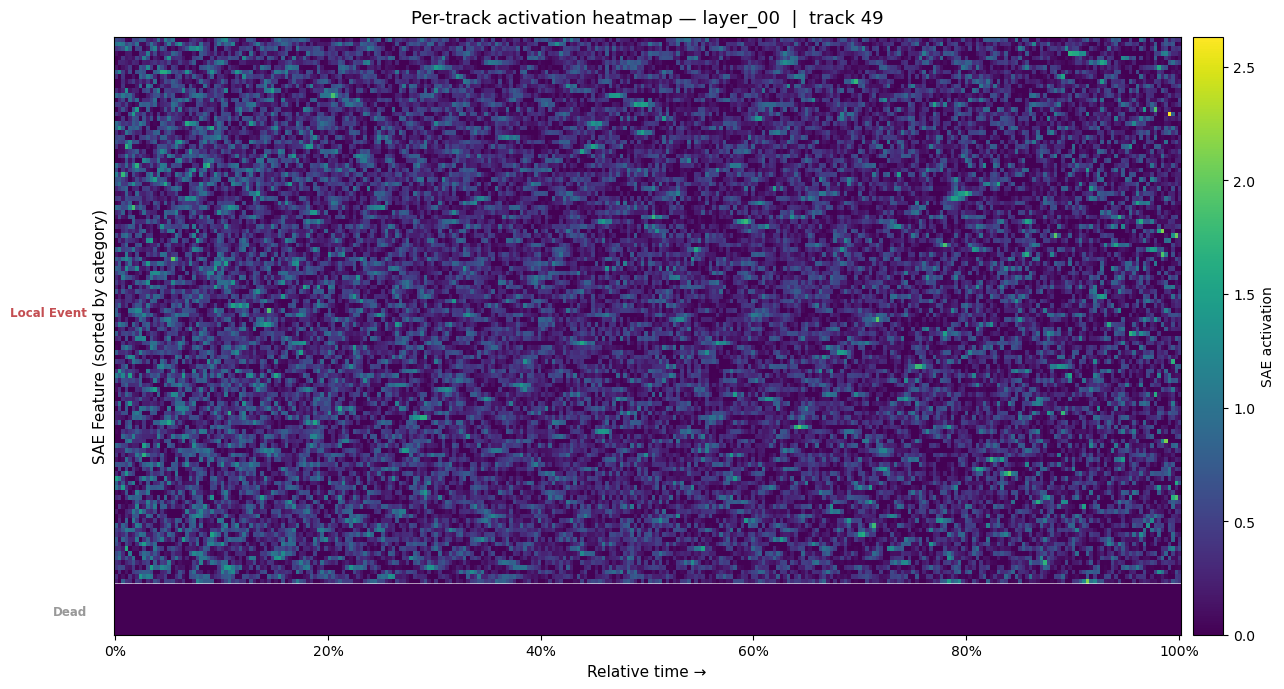

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_00_track74.png


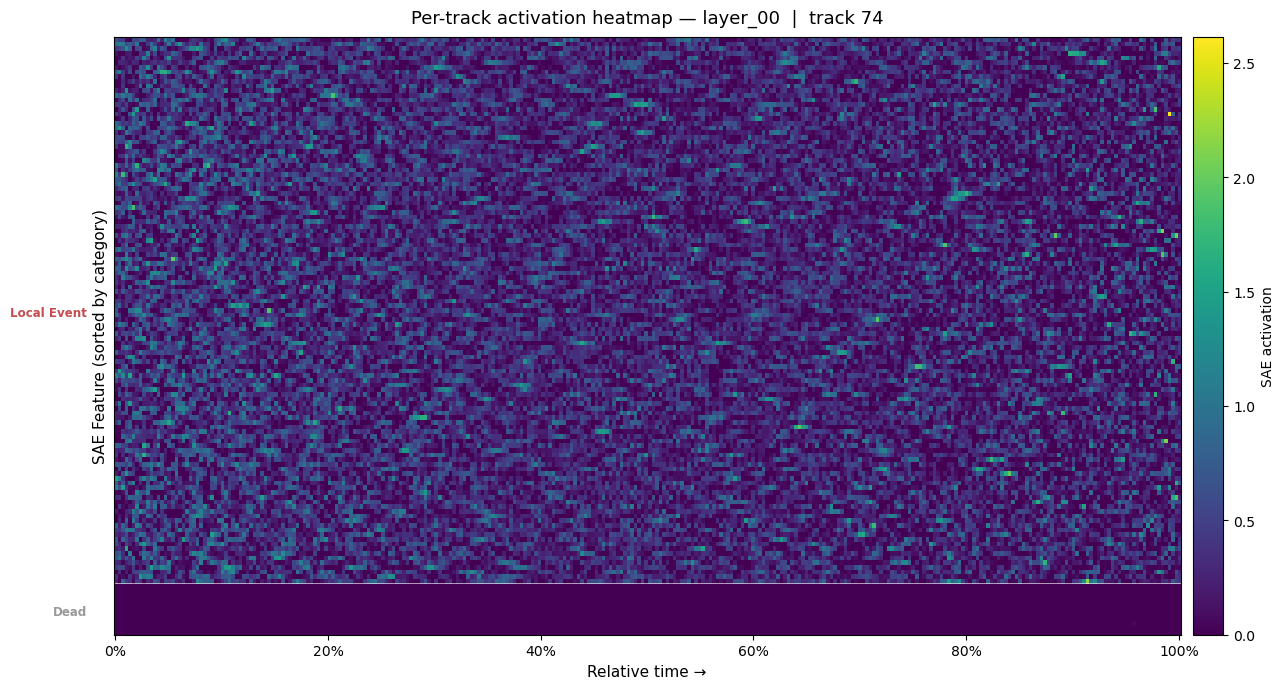

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_00_track99.png


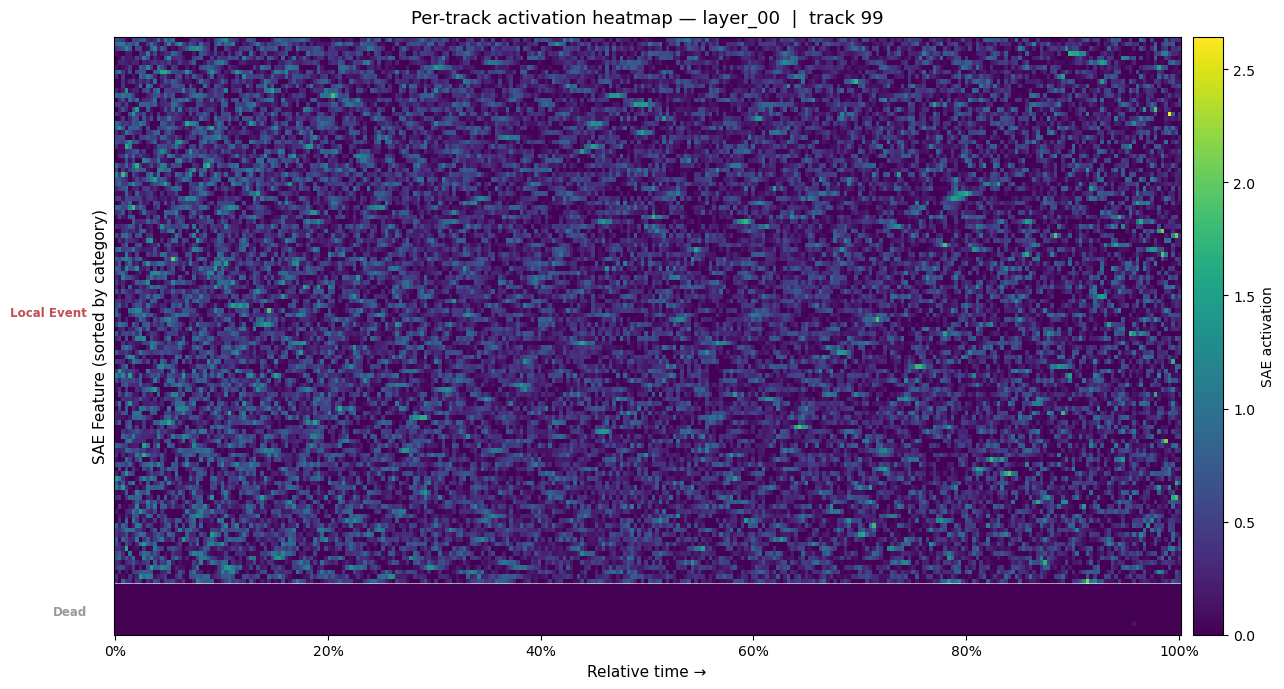

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_08_track0.png


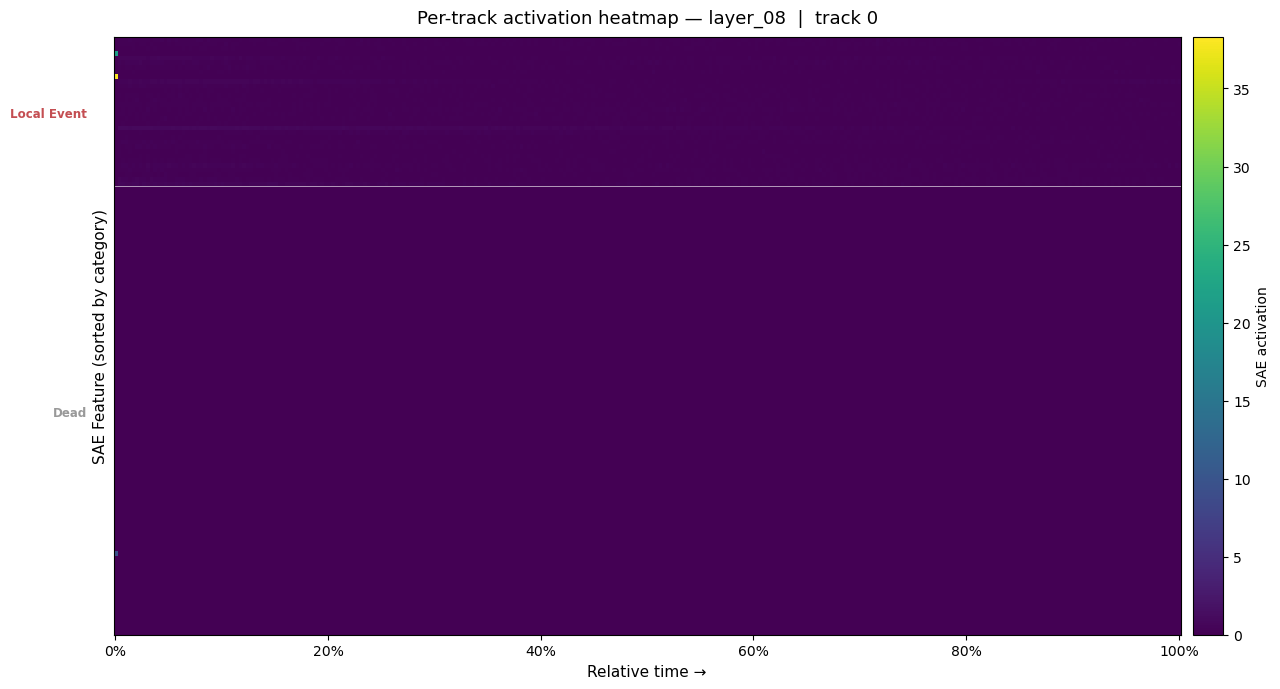

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_08_track24.png


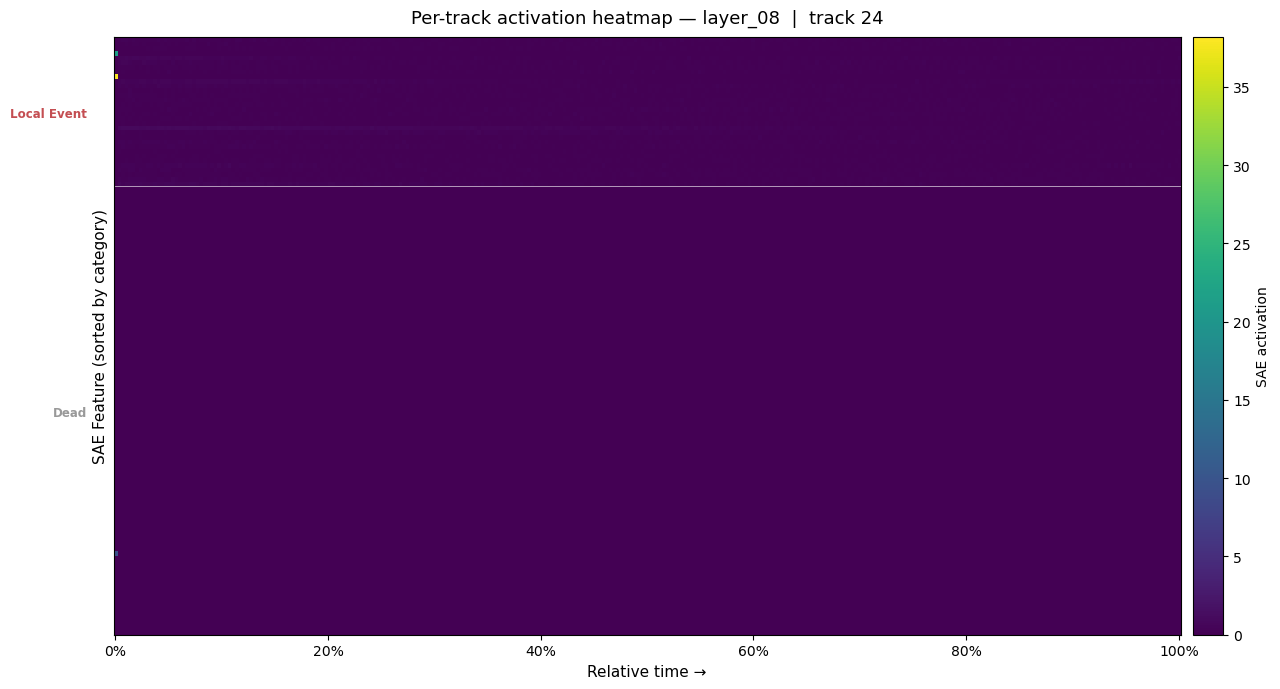

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_08_track49.png


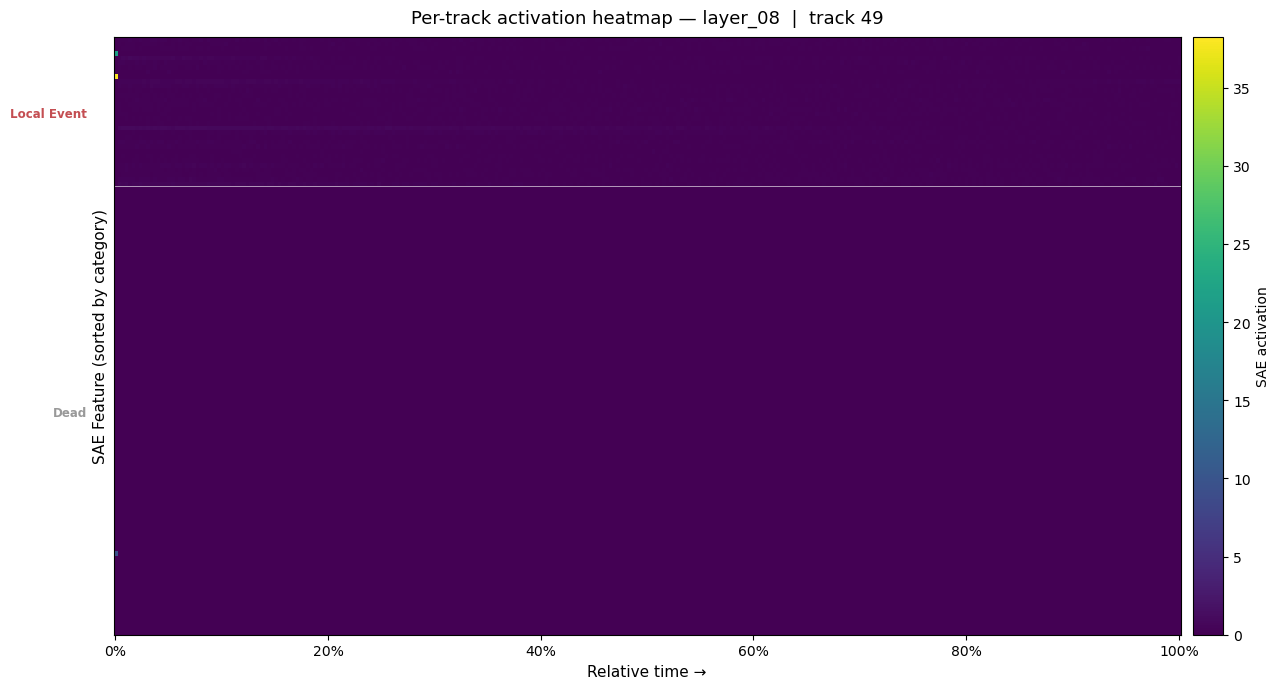

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_08_track74.png


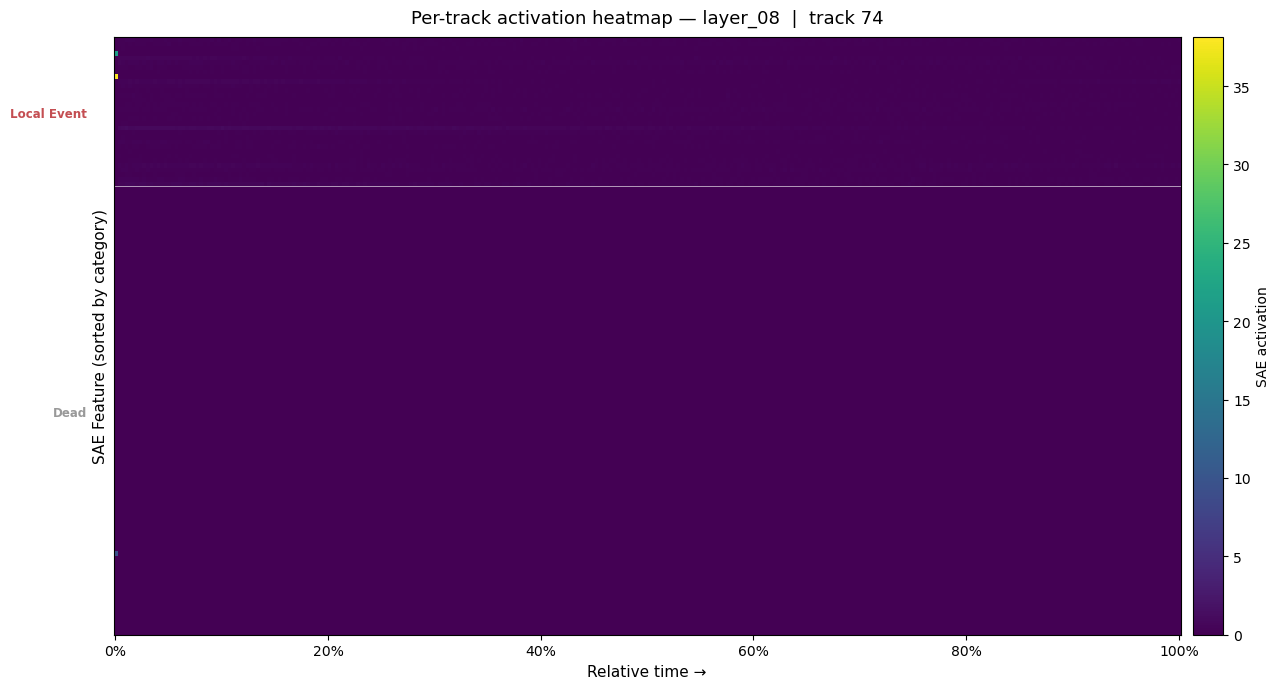

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_08_track99.png


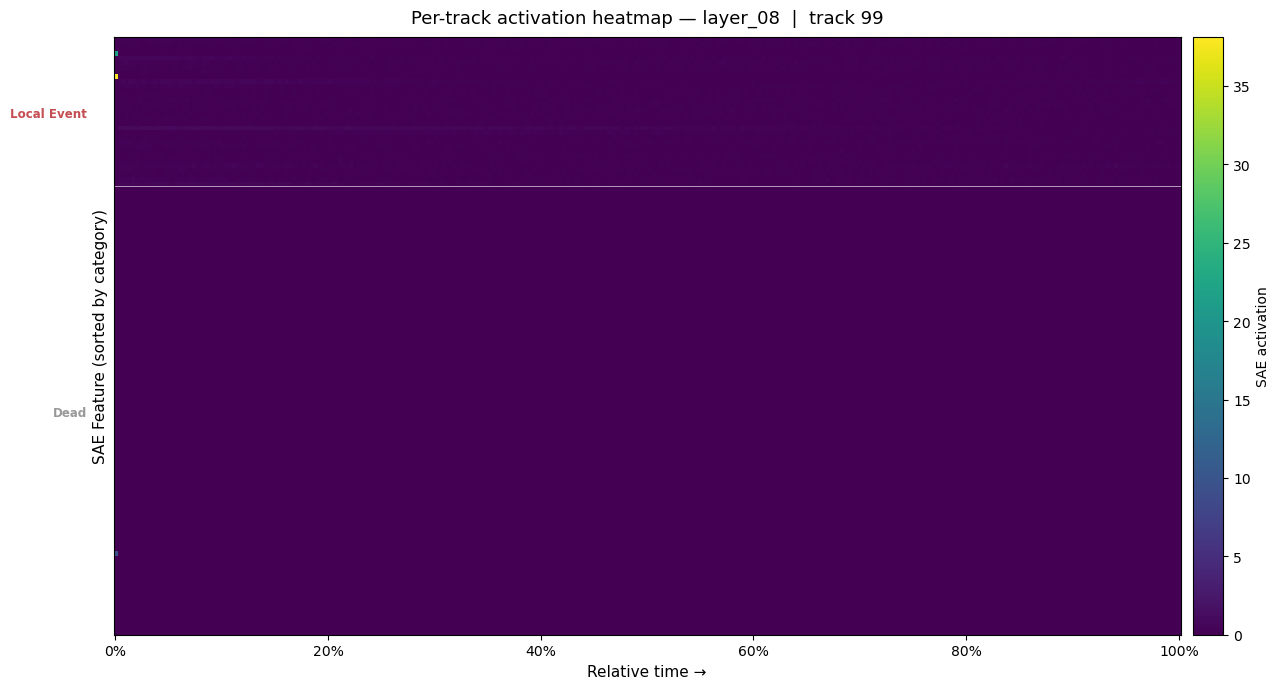

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_16_track0.png


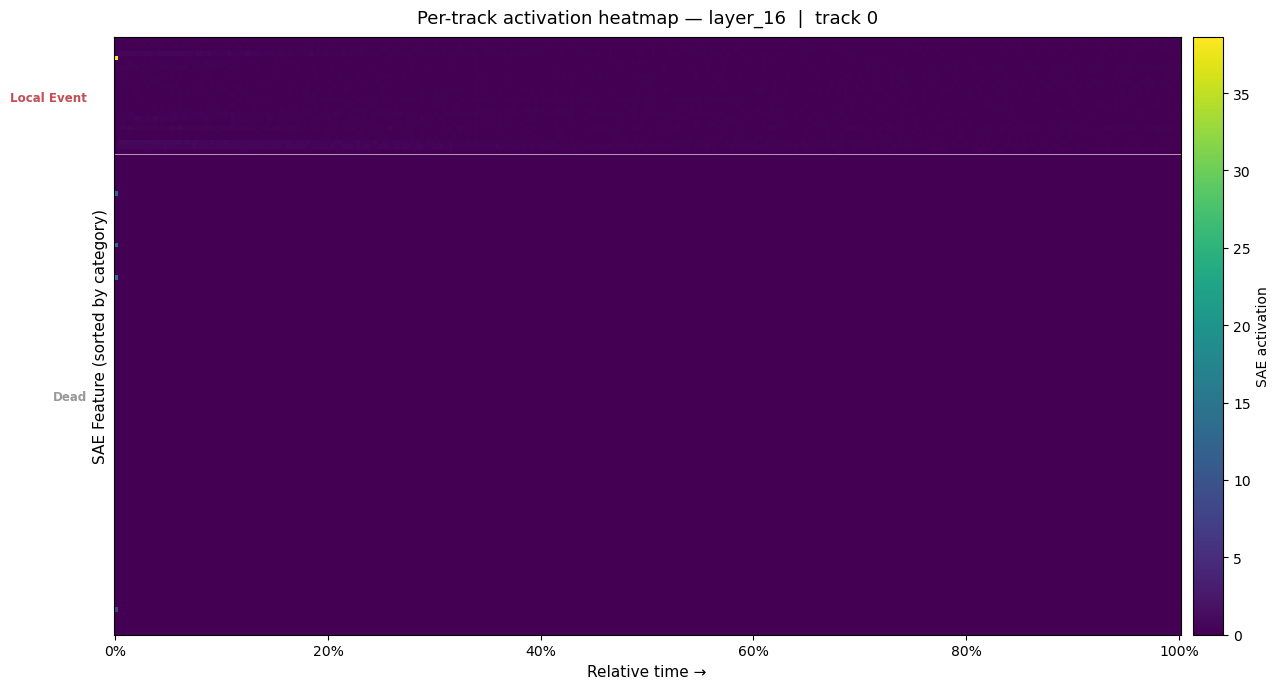

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_16_track24.png


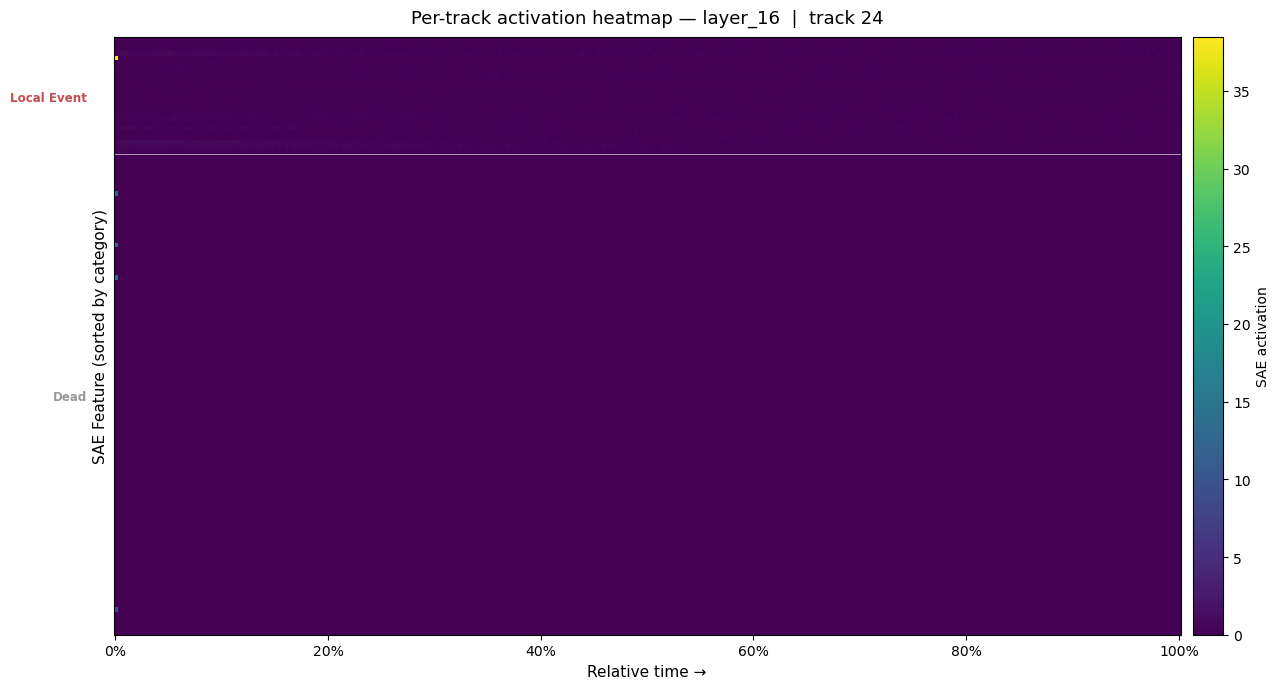

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_16_track49.png


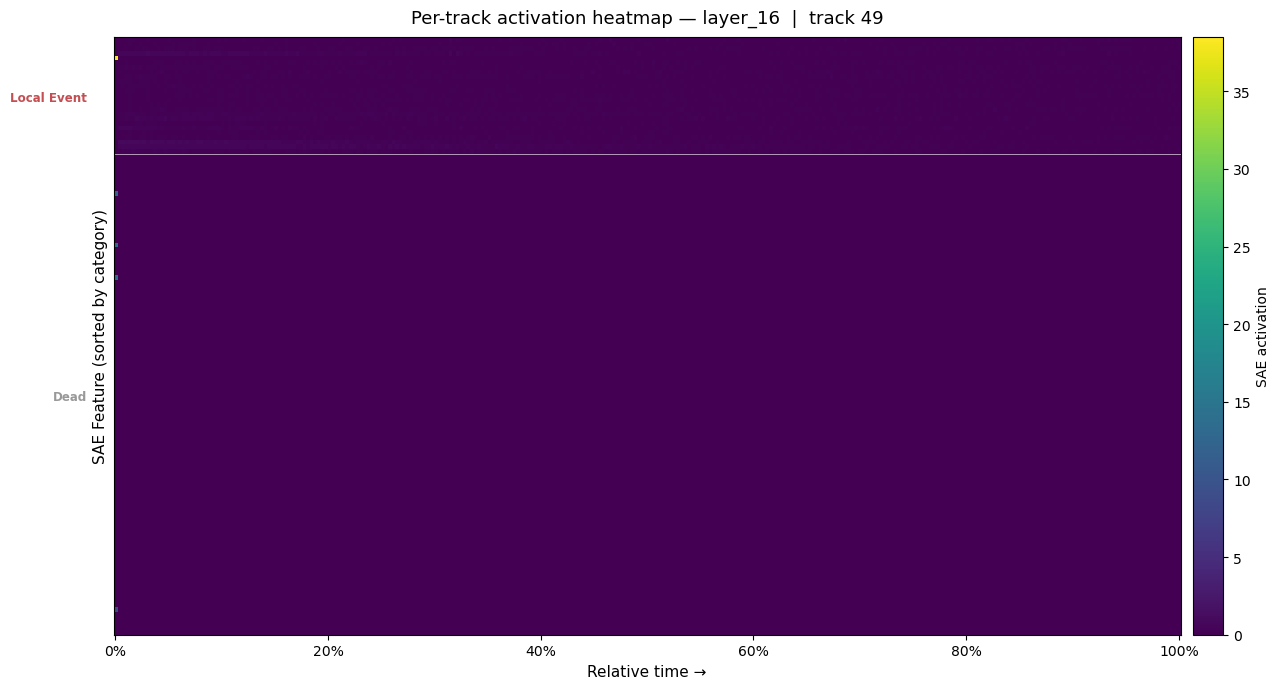

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_16_track74.png


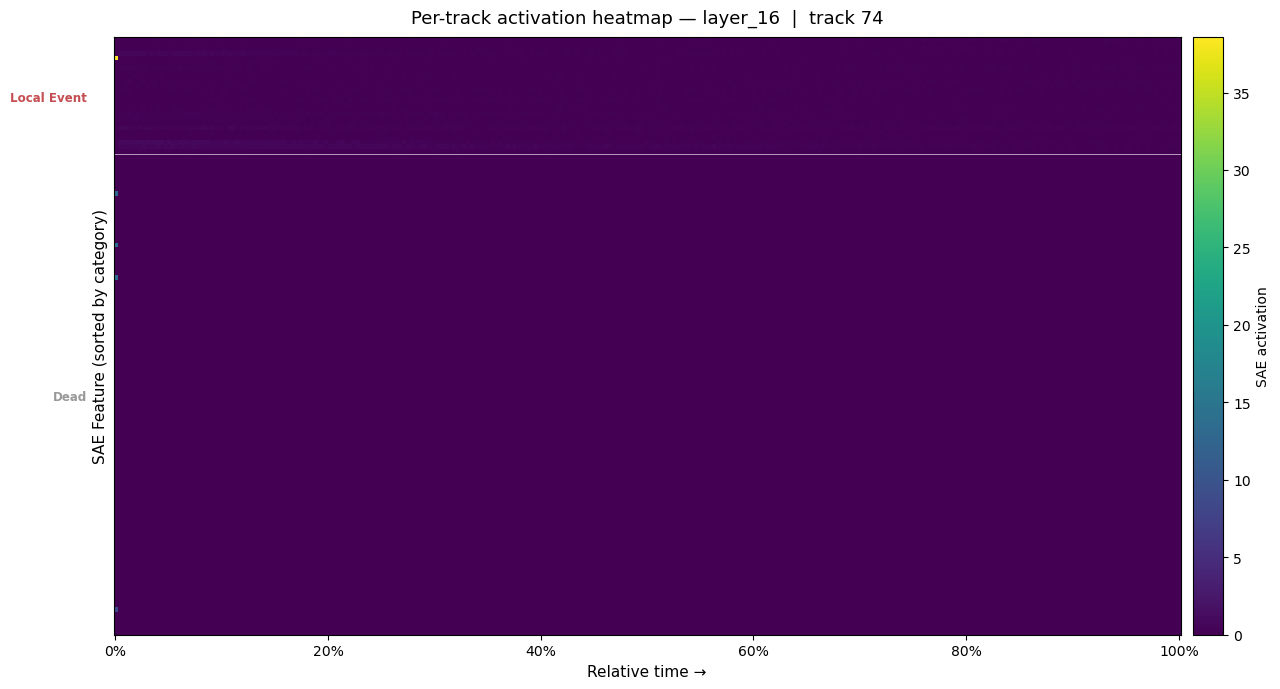

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer_16_track99.png


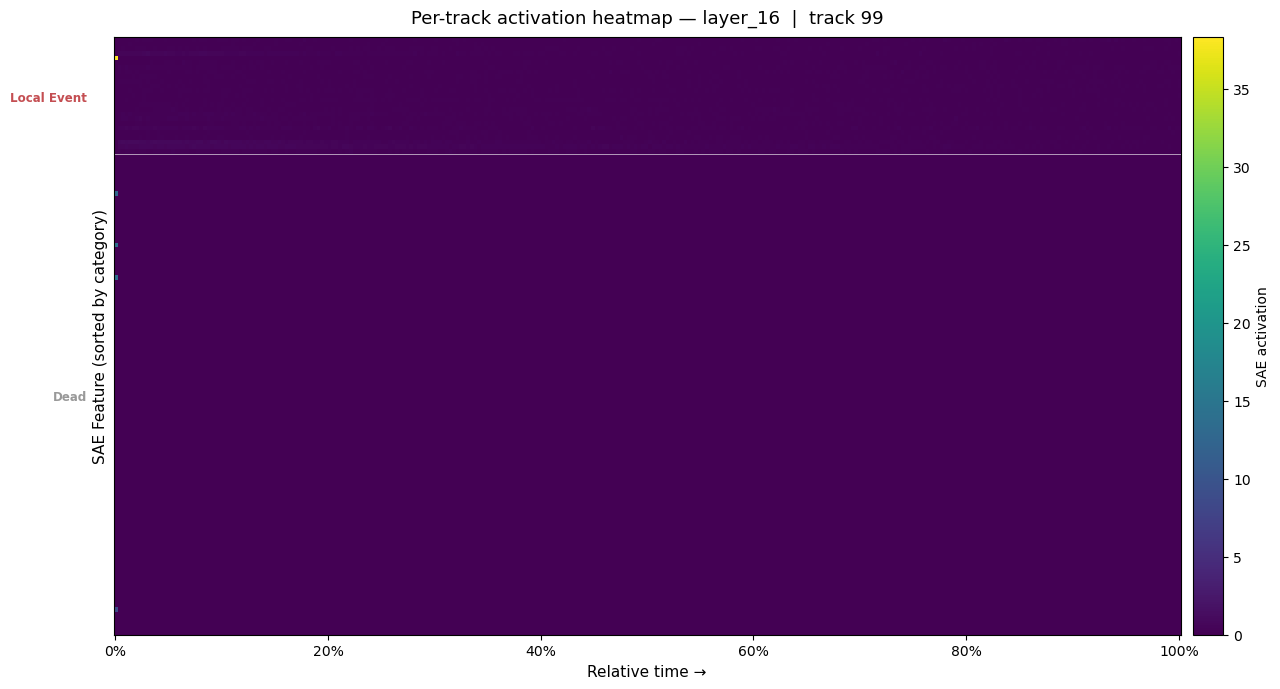

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final_track0.png


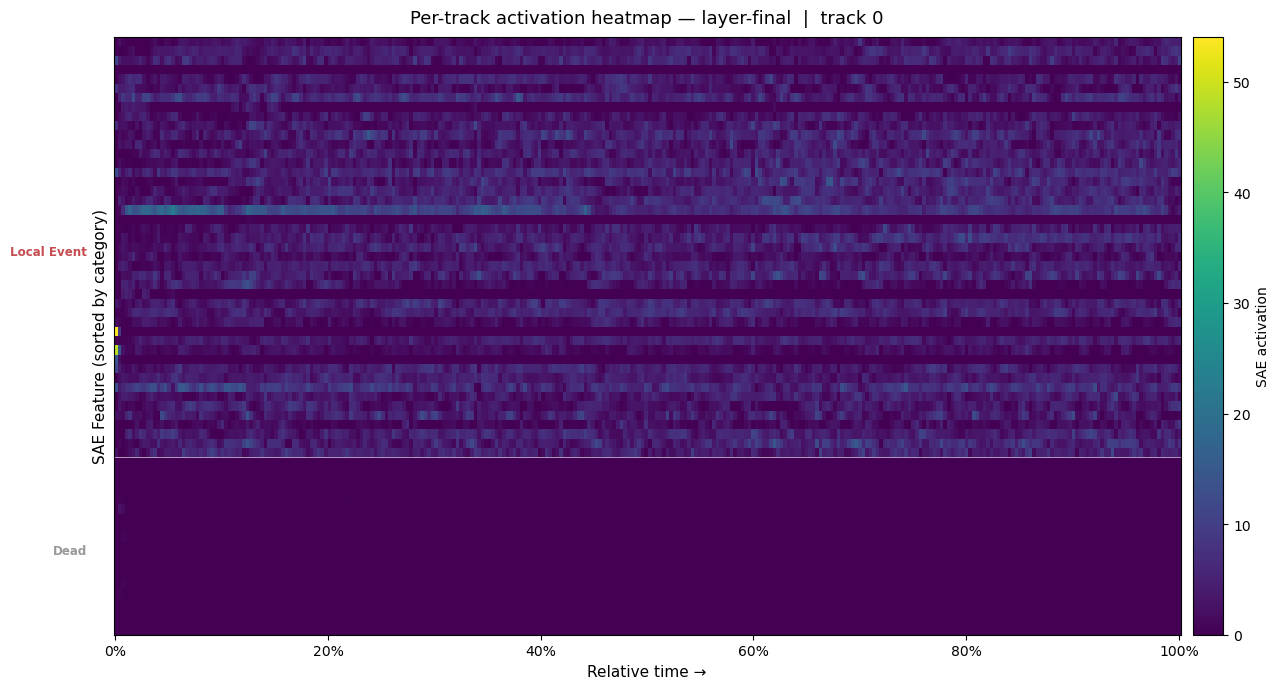

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final_track24.png


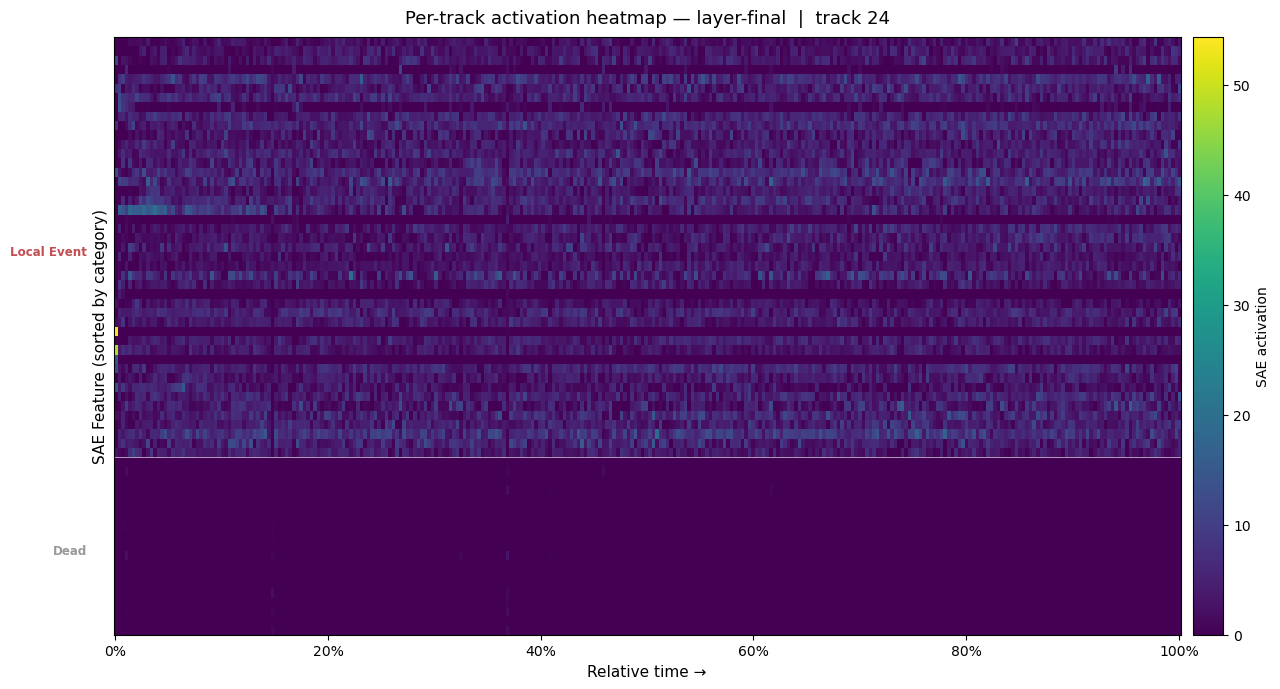

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final_track49.png


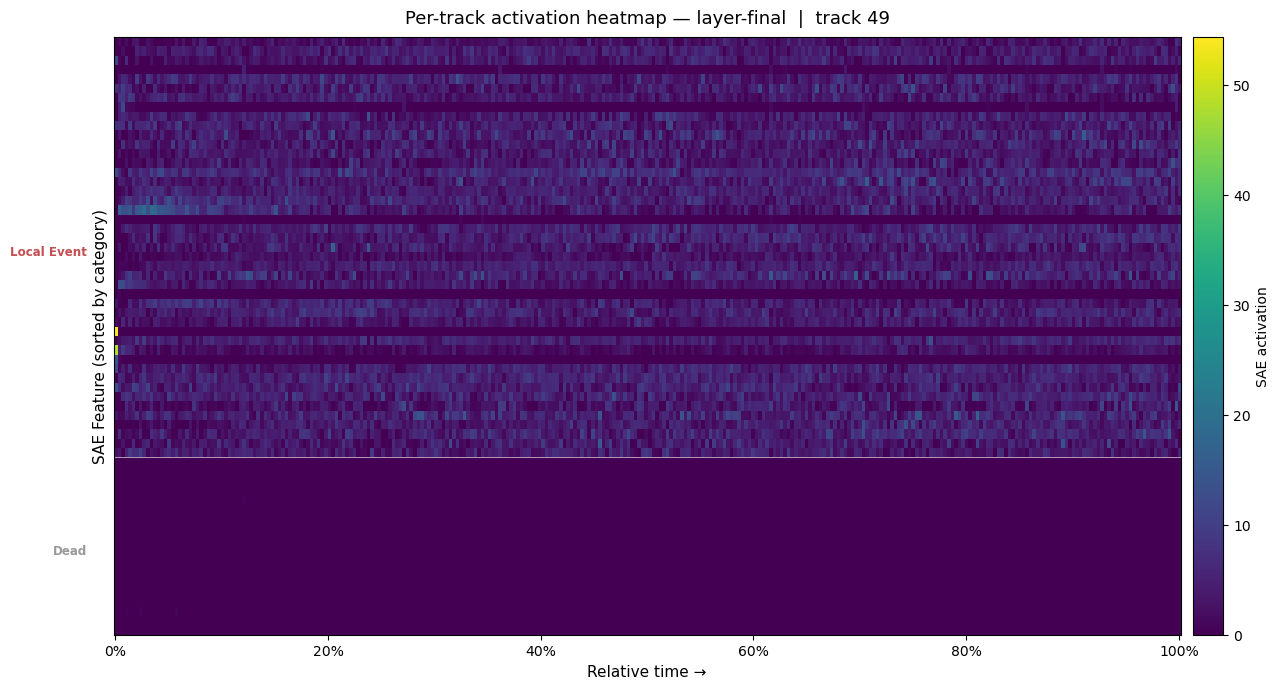

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final_track74.png


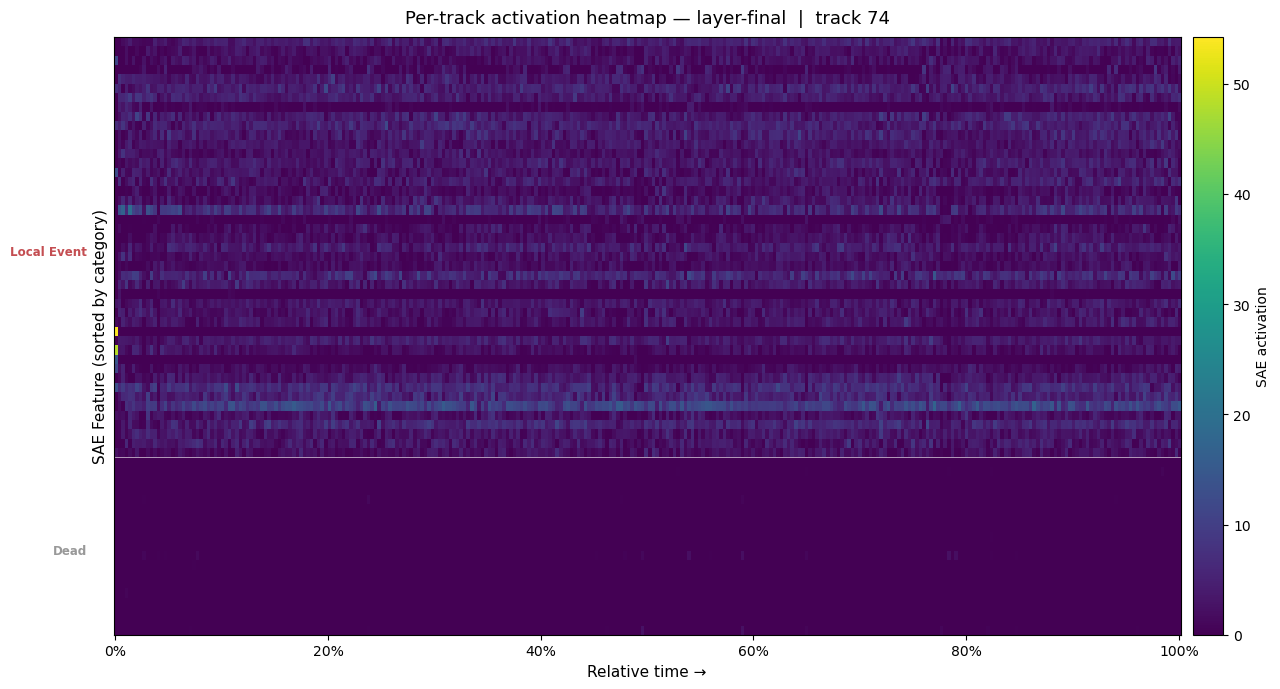

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final_track99.png


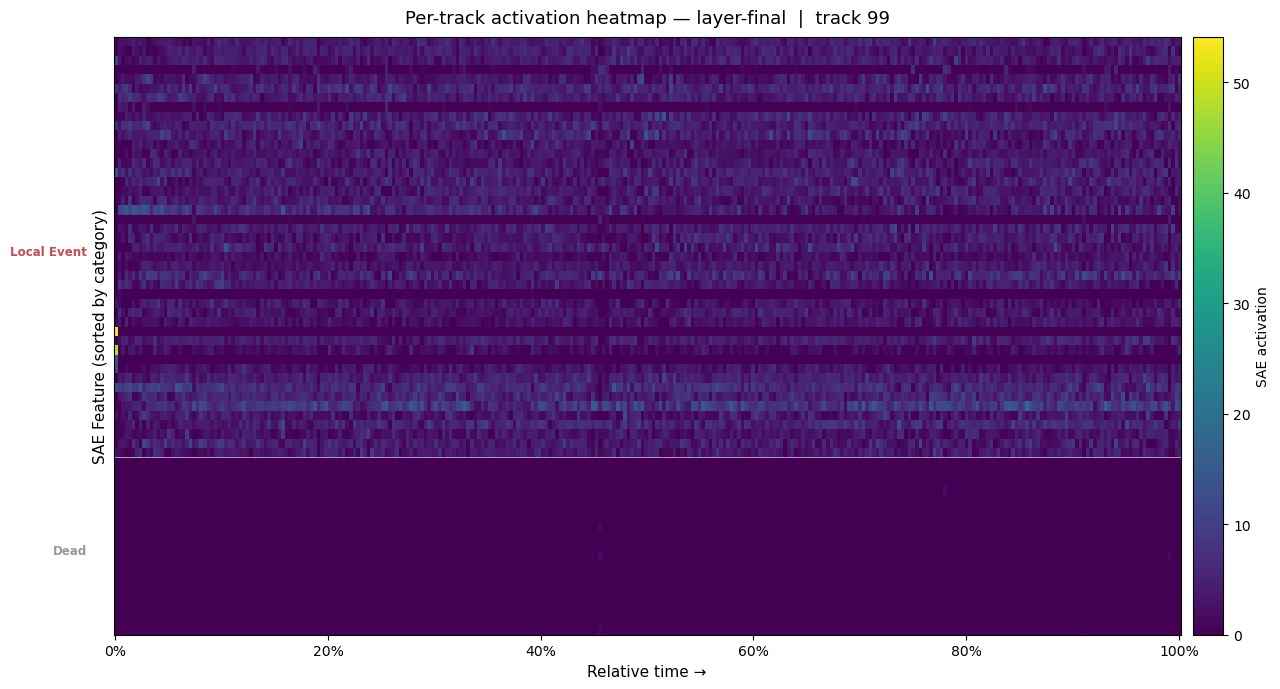

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final-large-01_track0.png


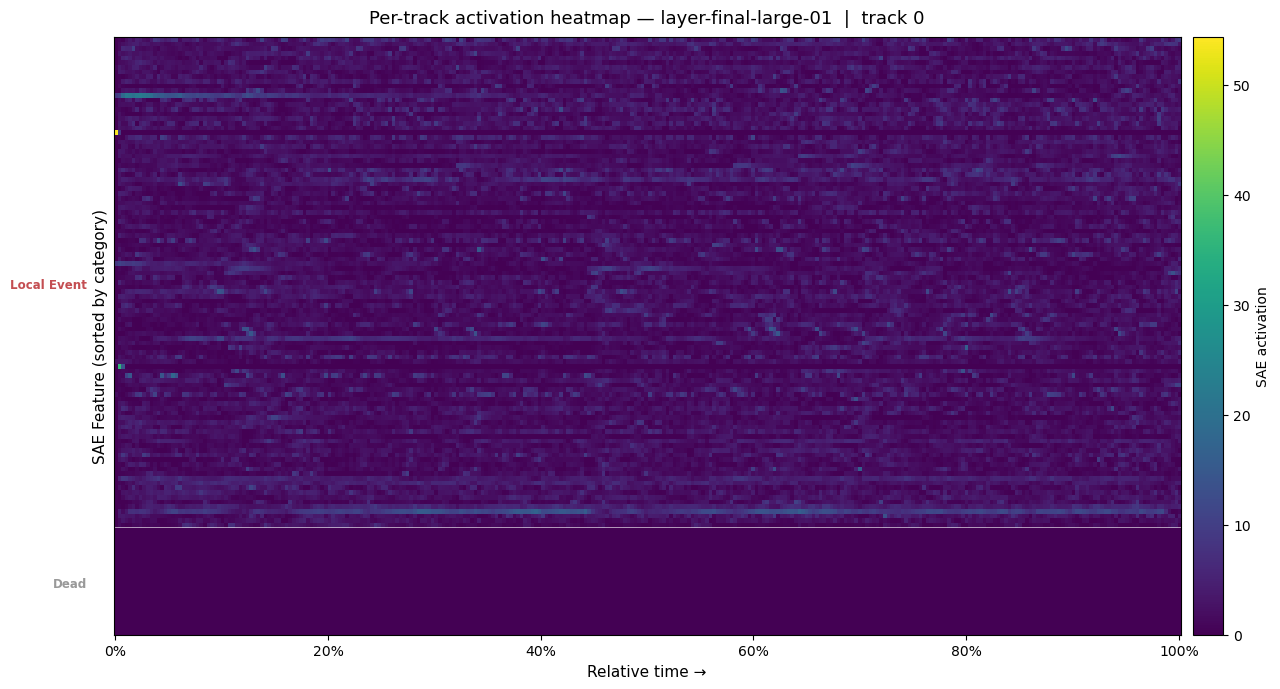

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final-large-01_track24.png


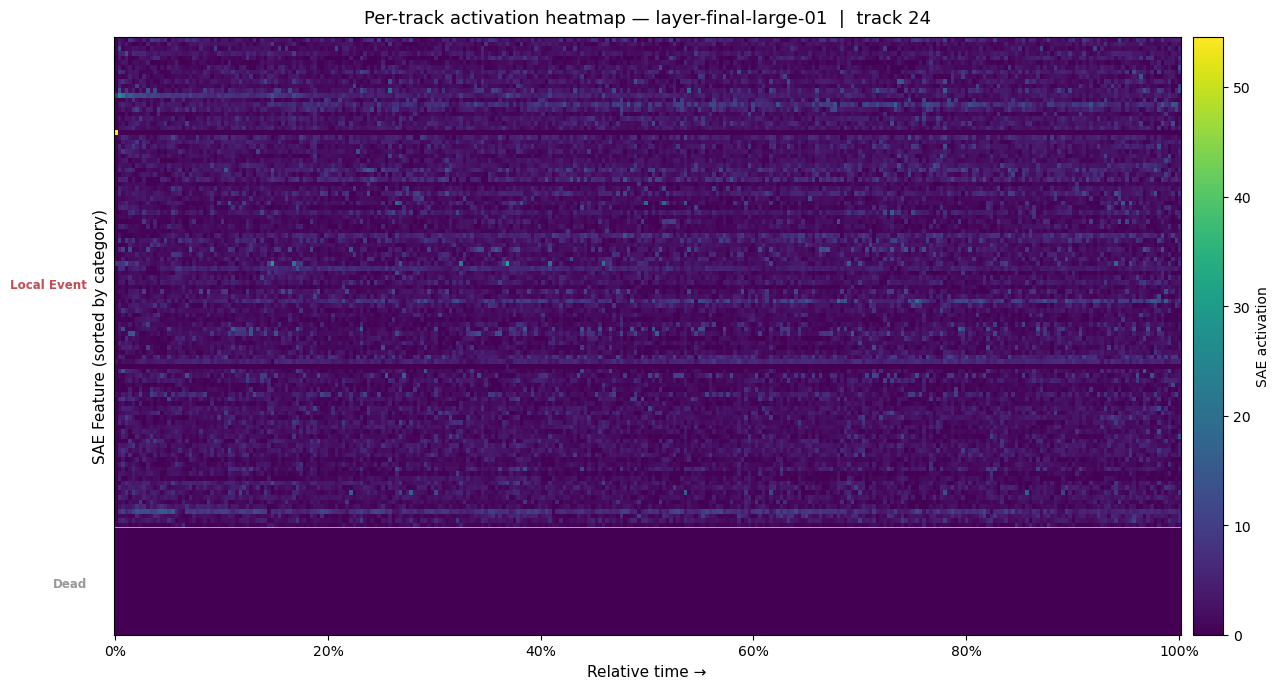

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final-large-01_track49.png


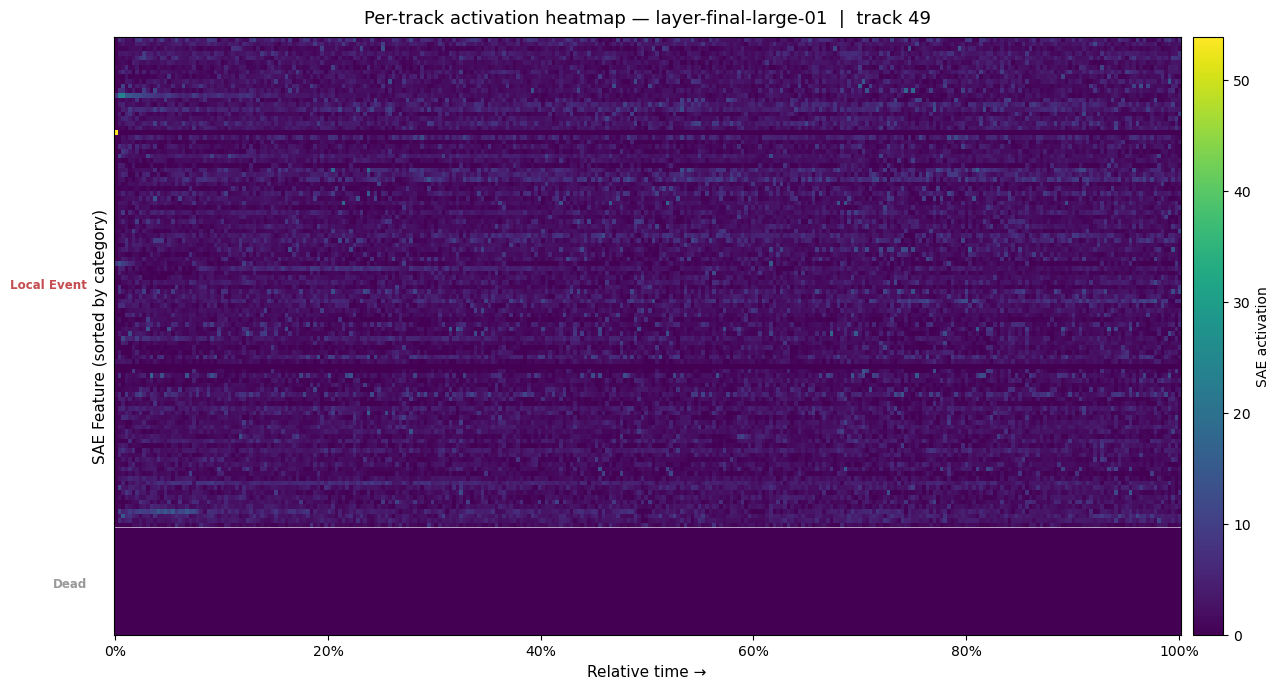

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final-large-01_track74.png


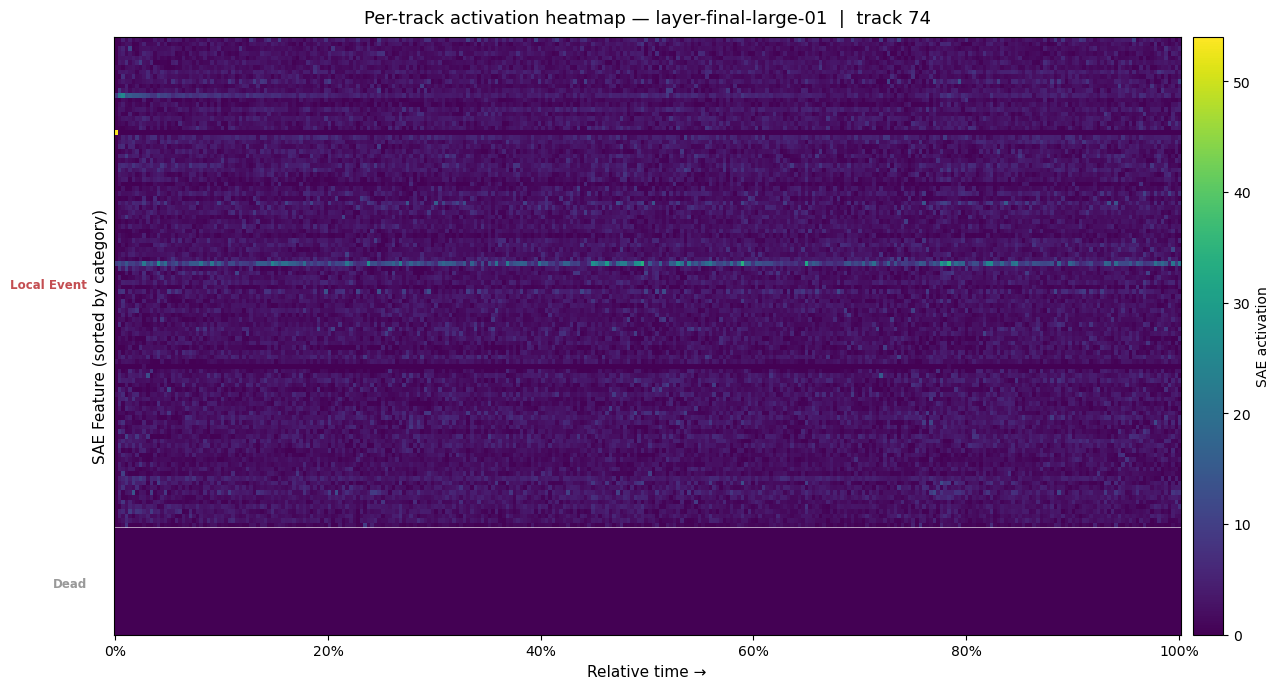

Saved: /Users/alexanderfraser/Documents/University-of-Utah/CS6966_Interpretability_of_LLMs/Interpretability-of-Temporal-Music-Activations-in-AudioGen/Output/analysis_heatmap_layer-final-large-01_track99.png


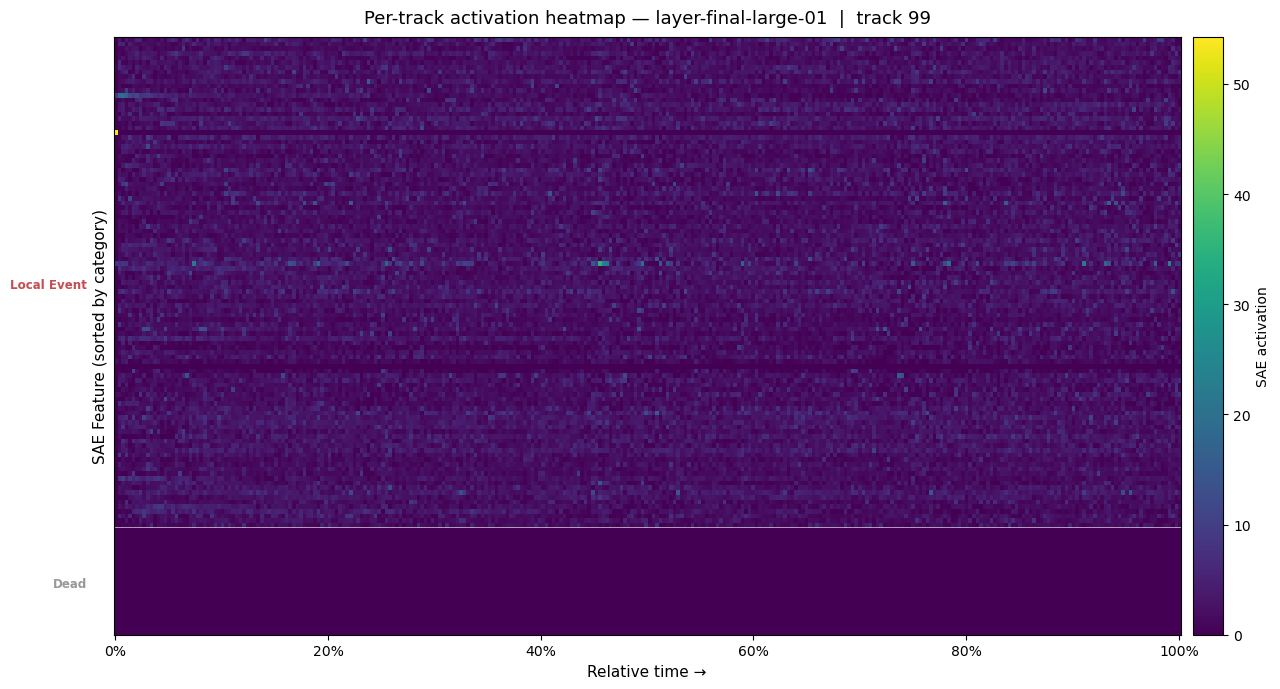

In [ ]:
def feature_sort_order(labels: np.ndarray) -> np.ndarray:
    """Sort feature indices by category order, then by feature index within each category."""
    order = []
    for category in CATEGORIES:
        order.extend(np.where(labels == category)[0].tolist())
    return np.array(order)


def category_boundaries(labels: np.ndarray, sort_order: np.ndarray) -> Dict[str, Tuple[int, int]]:
    """Return {category: (start_row, end_row)} in the sorted heatmap."""
    sorted_labels = labels[sort_order]
    boundaries: Dict[str, Tuple[int, int]] = {}
    for category in CATEGORIES:
        indices = np.where(sorted_labels == category)[0]
        if len(indices):
            boundaries[category] = (int(indices[0]), int(indices[-1]) + 1)
    return boundaries


def plot_track_heatmap(layer_name: str, track_idx: int, n_bins: int = 300):
    track_acts = activations[layer_name]
    labels = labels_per_layer[layer_name]
    sort_order = feature_sort_order(labels)
    boundaries = category_boundaries(labels, sort_order)

    act = track_acts[track_idx]
    latent_dim = act.shape[1]

    x_old = np.linspace(0, 1, act.shape[0])
    x_new = np.linspace(0, 1, n_bins)
    act_resampled = np.stack(
        [np.interp(x_new, x_old, act[:, feature_idx]) for feature_idx in range(latent_dim)],
        axis=0,
    )

    act_sorted = act_resampled[sort_order, :]

    fig, ax = plt.subplots(figsize=(14, 7))
    image = ax.imshow(
        act_sorted,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        origin="upper",
    )
    plt.colorbar(image, ax=ax, label="SAE activation", pad=0.01)

    for category, (start, end) in boundaries.items():
        if start == end:
            continue
        ax.axhline(start - 0.5, color="white", linewidth=0.6, alpha=0.7)
        midpoint = (start + end) / 2
        ax.text(
            -8,
            midpoint,
            category,
            ha="right",
            va="center",
            fontsize=8.5,
            color=CATEGORY_COLORS.get(category, "black"),
            fontweight="bold",
        )

    ax.set_xlabel("Relative time", fontsize=11)
    ax.set_ylabel("SAE feature (sorted by category)", fontsize=11)
    ax.set_title(f"Per-Track Activation Heatmap - {layer_name} | track {track_idx}", fontsize=13, pad=10)
    ax.set_yticks([])
    ax.set_xticks(np.linspace(0, n_bins - 1, 6))
    ax.set_xticklabels([f"{int(percent)}%" for percent in np.linspace(0, 100, 6)])

    plt.tight_layout()
    out_path = OUTPUT_DIR / f"analysis_heatmap_{layer_name}_track{track_idx}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()


for layer_name in labels_per_layer:
    n_tracks = len(activations[layer_name])
    indices = np.linspace(0, n_tracks - 1, min(VIS_TRACKS, n_tracks), dtype=int)
    for index in indices:
        plot_track_heatmap(layer_name, track_idx=int(index))

## 8 · Cross-Layer Comparison

With all 24 SAEs available, this section compares temporal feature structure across
the full MusicGen decoder stack.

This section produces:
1. A stacked bar chart of feature-category proportions by layer.
2. Mean diagnostic statistics per layer.
3. Activation sparsity curves across layers.

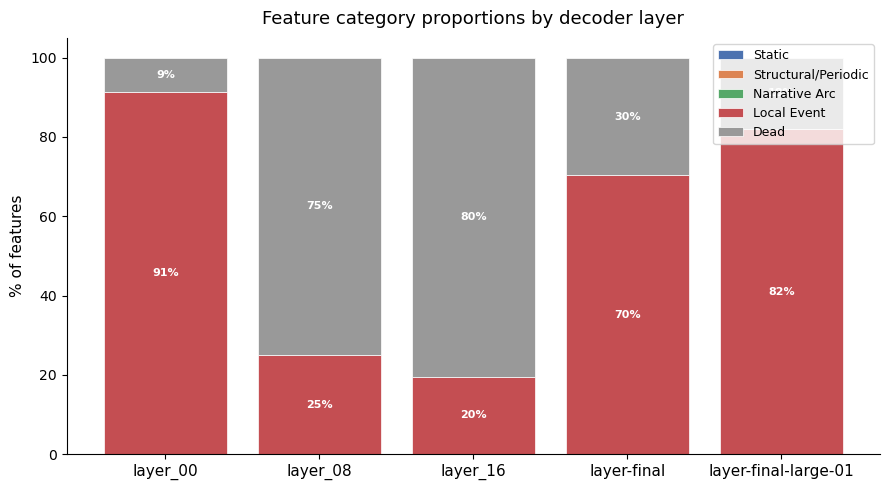

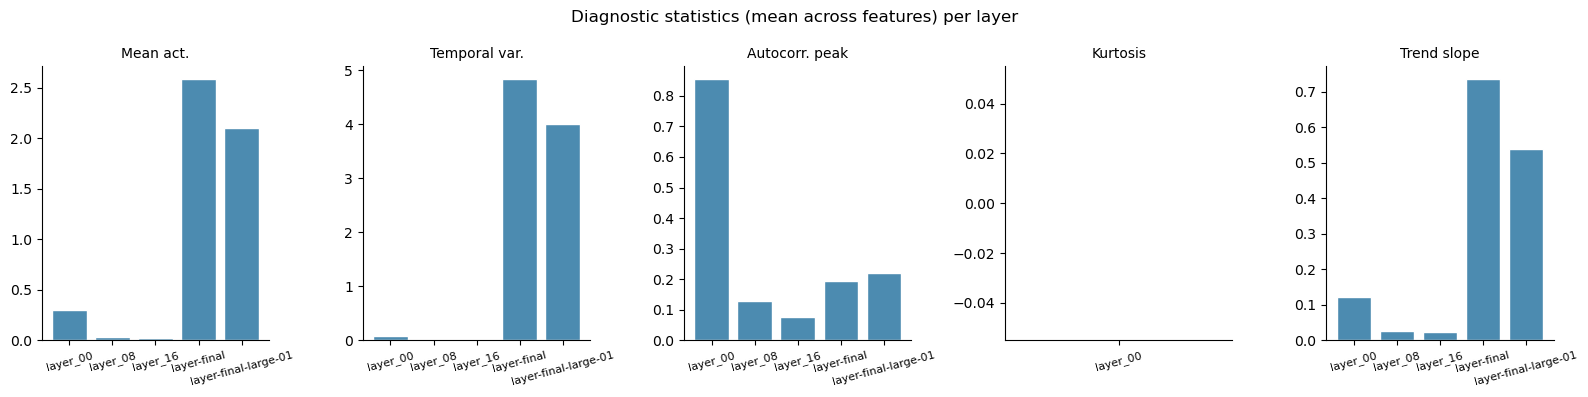

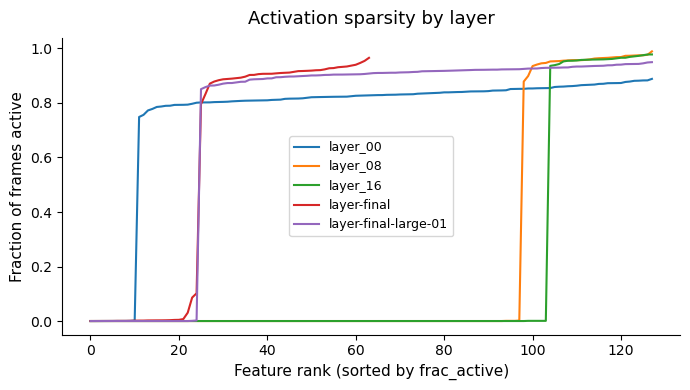

In [ ]:
if len(labels_per_layer) < 2:
    print("Only one layer available so far - re-run this cell once at least two SAEs are loaded.")
else:
    fig, ax = plt.subplots(figsize=(12, 5.5))
    layer_order = [layer for layer in LAYER_NAMES if layer in labels_per_layer]
    x = np.arange(len(layer_order))
    bottoms = np.zeros(len(layer_order))

    for category in CATEGORIES:
        proportions = np.array([(labels_per_layer[layer] == category).mean() for layer in layer_order])
        ax.bar(
            x,
            proportions * 100,
            bottom=bottoms,
            label=category,
            color=CATEGORY_COLORS[category],
            edgecolor="white",
            linewidth=0.5,
        )
        for idx, (bottom, proportion) in enumerate(zip(bottoms, proportions * 100)):
            if proportion > 5:
                ax.text(
                    idx,
                    bottom + proportion / 2,
                    f"{proportion:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white",
                    fontweight="bold",
                )
        bottoms += proportions * 100

    ax.set_xticks(x)
    ax.set_xticklabels(layer_order, fontsize=8, rotation=45, ha="right")
    ax.set_ylabel("% of features", fontsize=11)
    ax.set_title("Feature Category Proportions by Decoder Layer", fontsize=13, pad=10)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, framealpha=0.8)
    ax.set_ylim(0, 105)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "analysis_cross_layer_categories.png", dpi=150, bbox_inches="tight")
    plt.show()

    diag_fields = ["mean_act", "temporal_var", "autocorr_peak", "kurtosis", "trend_slope"]
    diag_labels = ["Mean act.", "Temporal var.", "Autocorr. peak", "Kurtosis", "Trend slope"]

    fig, axes = plt.subplots(1, len(diag_fields), figsize=(18, 4.5))
    fig.suptitle("Diagnostic Statistics (Mean Across Features) per Layer", fontsize=12)

    for axis, field, label in zip(axes, diag_fields, diag_labels):
        values = np.array([stats_per_layer[layer][field].mean() for layer in layer_order])
        axis.bar(layer_order, values, color="#4C8BB0", edgecolor="white")
        axis.set_title(label, fontsize=10)
        axis.tick_params(axis="x", labelsize=8, rotation=45)
        for tick in axis.get_xticklabels():
            tick.set_ha("right")
        for spine in ["top", "right"]:
            axis.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "analysis_cross_layer_stats.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for layer_name in layer_order:
        frac_active = stats_per_layer[layer_name]["frac_active"]
        ax.plot(np.arange(len(frac_active)), np.sort(frac_active), label=layer_name, linewidth=1.2)

    ax.set_xlabel("Feature rank (sorted by frac_active)", fontsize=11)
    ax.set_ylabel("Fraction of frames active", fontsize=11)
    ax.set_title("Activation Sparsity by Layer", fontsize=13, pad=10)
    ax.legend(fontsize=7, ncol=4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "analysis_cross_layer_sparsity.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9 · Achieving Very High Sparsity

If you want **much sparser activations** (most features inactive most of the time), you need to increase the sparsity penalty during training.

**How sparsity is controlled:**
- The SAE training loss is: `L = recon_loss + λ × L1_loss`
- Larger `λ` (sparsity penalty) forces more features to stay at 0
- The `avg_sparsity` in training metrics is the actual penalty term being optimized, not a target `frac_active`

**To retrain with very high sparsity:**

```bash
# Re-train layer-final-large-01 with drastically higher sparsity penalty
python Temporal-Music-Activations/TrainNewSAE.py \
  --data_dir Data/Models/features/layer_final \
  --output_dir Output/sae-layer-final-very-sparse \
  --device mps \
  --epochs 80 \
  --batch_size 16 \
  --latent_dim 128 \
  --sparsity_weight 1.0 \
  --sample_mode frames \
  --frame_stride 1 \
  --checkpoint_interval 5
```

**Sparsity penalty guidelines:**
- **0.01–0.05**: Low sparsity (most features active, dense codes)
- **0.1–0.5**: Moderate sparsity (typical default)
- **1.0–5.0**: High sparsity (few features active at any time)
- **10+**: Very high sparsity (only a handful of features per frame)

**Trade-off:** Higher sparsity = fewer active features, but reconstruction error will increase. Run cell 2 again after retraining to see the new `frac_active` distribution.